In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [4]:
import pandas as pd

DATA_PATH = "/kaggle/input/competitions/ieee-fraud-detection"

train = pd.read_csv(
    f"{DATA_PATH}/train_transaction.csv"
)

print("Shape:", train.shape)
print("Fraud cases:", train["isFraud"].sum())
print("Fraud rate:", train["isFraud"].mean())

Shape: (590540, 394)
Fraud cases: 20663
Fraud rate: 0.03499000914417313


In [5]:
print(train.info())
print(train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB
None
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  .

In [6]:
# Basic inspection
print("Shape:", train.shape)
print("\nFraud distribution:")
print(train["isFraud"].value_counts())

print("\nFraud percentage:")
print(train["isFraud"].mean() * 100)

print("\nData types:")
print(train.dtypes.value_counts())

print("\nMissing values — top 20:")
print(train.isna().sum().sort_values(ascending=False).head(20))

Shape: (590540, 394)

Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud percentage:
3.4990009144173126

Data types:
float64    376
object      14
int64        4
Name: count, dtype: int64

Missing values — top 20:
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
dtype: int64


In [7]:
# Memory optimization
float_cols = train.select_dtypes(include=["float64"]).columns
int_cols = train.select_dtypes(include=["int64"]).columns

train[float_cols] = train[float_cols].astype("float32")
train[int_cols] = train[int_cols].astype("int32")

print("Memory optimization complete.")

Memory optimization complete.


In [8]:
train = train.sort_values("TransactionDT").reset_index(drop=True)

split_idx = int(len(train) * 0.80)

train_df = train.iloc[:split_idx].copy()
valid_df = train.iloc[split_idx:].copy()

print("Training:", train_df.shape)
print("Validation:", valid_df.shape)

print("\nLatest training time:")
print(train_df["TransactionDT"].max())

print("\nEarliest validation time:")
print(valid_df["TransactionDT"].min())

Training: (472432, 394)
Validation: (118108, 394)

Latest training time:
12192842

Earliest validation time:
12192900


In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score

X_train = train_df[["TransactionDT"]]
X_valid = valid_df[["TransactionDT"]]

y_train = train_df["isFraud"]
y_valid = valid_df["isFraud"]

dummy = DummyClassifier(strategy="prior")

dummy.fit(X_train, y_train)

dummy_probs = dummy.predict_proba(X_valid)[:, 1]

dummy_pr_auc = average_precision_score(y_valid, dummy_probs)

print("Dummy PR-AUC:", dummy_pr_auc)

Dummy PR-AUC: 0.034409184813899145


In [10]:
import numpy as np

features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6"
]

X_train = train_df[features].copy()
X_valid = valid_df[features].copy()

y_train = train_df["isFraud"]
y_valid = valid_df["isFraud"]

X_train["TransactionAmt"] = np.log1p(X_train["TransactionAmt"])
X_valid["TransactionAmt"] = np.log1p(X_valid["TransactionAmt"])

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

numeric_features = ["TransactionAmt"]

categorical_features = [
    "ProductCD",
    "card4",
    "card6"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_probs = logistic_model.predict_proba(X_valid)[:, 1]

logistic_pr_auc = average_precision_score(
    y_valid,
    logistic_probs
)

logistic_roc_auc = roc_auc_score(
    y_valid,
    logistic_probs
)

print("Logistic PR-AUC:", logistic_pr_auc)
print("Logistic ROC-AUC:", logistic_roc_auc)

Logistic PR-AUC: 0.12321600517593911
Logistic ROC-AUC: 0.7433701262853514


In [12]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_probs = tree_model.predict_proba(X_valid)[:, 1]

tree_pr_auc = average_precision_score(
    y_valid,
    tree_probs
)

tree_roc_auc = roc_auc_score(
    y_valid,
    tree_probs
)

print("Decision Tree PR-AUC:", tree_pr_auc)
print("Decision Tree ROC-AUC:", tree_roc_auc)

Decision Tree PR-AUC: 0.11689999464059513
Decision Tree ROC-AUC: 0.7402850244618253


In [13]:
!pip install lightgbm -q

In [14]:
from lightgbm import LGBMClassifier

X_train_lgb = train_df[features].copy()
X_valid_lgb = valid_df[features].copy()

for col in ["ProductCD", "card4", "card6"]:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_valid_lgb[col] = X_valid_lgb[col].astype("category")

y_train = train_df["isFraud"]
y_valid = valid_df["isFraud"]

In [15]:
boost_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

boost_model.fit(
    X_train_lgb,
    y_train,
    categorical_feature=[
        "ProductCD",
        "card4",
        "card6"
    ]
)

boost_probs = boost_model.predict_proba(
    X_valid_lgb
)[:, 1]

boost_pr_auc = average_precision_score(
    y_valid,
    boost_probs
)

boost_roc_auc = roc_auc_score(
    y_valid,
    boost_probs
)

print("LightGBM PR-AUC:", boost_pr_auc)
print("LightGBM ROC-AUC:", boost_roc_auc)

LightGBM PR-AUC: 0.13827094708929535
LightGBM ROC-AUC: 0.7668264191079587


In [16]:
features_52 = [
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",

    "card1", "card2", "card3", "card4",
    "card5", "card6",

    "addr1", "addr2",

    "P_emaildomain",
    "R_emaildomain",

    "C1", "C2", "C3", "C4", "C5", "C6", "C7",
    "C8", "C9", "C10", "C11", "C12", "C13", "C14",

    "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "D8", "D9", "D10", "D11", "D12", "D13", "D14",
    "D15",

    "M1", "M2", "M3", "M4", "M5",
    "M6", "M7", "M8", "M9",

    "dist1"
]

data_52 = train[features_52 + ["isFraud"]].copy()

print(data_52.shape)

(590540, 53)


In [17]:
data_52 = data_52.sort_values(
    "TransactionDT"
).reset_index(drop=True)

split_idx = int(len(data_52) * 0.80)

train_52 = data_52.iloc[:split_idx]
valid_52 = data_52.iloc[split_idx:]

X_train_52 = train_52.drop(columns=["isFraud"])
X_valid_52 = valid_52.drop(columns=["isFraud"])

y_train_52 = train_52["isFraud"]
y_valid_52 = valid_52["isFraud"]

categorical_cols = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "M1", "M2", "M3", "M4", "M5",
    "M6", "M7", "M8", "M9"
]

for col in categorical_cols:
    X_train_52[col] = X_train_52[col].astype("category")
    X_valid_52[col] = X_valid_52[col].astype("category")

print("Train:", X_train_52.shape)
print("Validation:", X_valid_52.shape)

Train: (472432, 52)
Validation: (118108, 52)


In [18]:
boost_model_52 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

boost_model_52.fit(
    X_train_52,
    y_train_52,
    categorical_feature=categorical_cols
)

probs_52 = boost_model_52.predict_proba(
    X_valid_52
)[:, 1]

pr_auc_52 = average_precision_score(
    y_valid_52,
    probs_52
)

roc_auc_52 = roc_auc_score(
    y_valid_52,
    probs_52
)

print("LightGBM 52-feature PR-AUC:", pr_auc_52)
print("LightGBM 52-feature ROC-AUC:", roc_auc_52)

LightGBM 52-feature PR-AUC: 0.526653856626605
LightGBM 52-feature ROC-AUC: 0.9090549409700828


In [19]:
importance = pd.DataFrame({
    "feature": X_train_52.columns,
    "importance": boost_model_52.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(
    importance.head(20).to_string(index=False)
)

       feature  importance
         card2         597
         card1         590
 TransactionDT         509
         addr1         476
TransactionAmt         459
 P_emaildomain         432
           D15         352
           C13         320
            D2         311
            C1         305
         card5         259
            D1         243
           D10         240
            D8         215
            D4         213
 R_emaildomain         206
           C14         200
            C2         196
            C6         194
         dist1         181


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

numeric_cols_52 = [
    col for col in X_train_52.columns
    if col not in categorical_cols
]

numeric_pipeline_52 = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", StandardScaler())
])

categorical_pipeline_52 = Pipeline([
    ("imputer", SimpleImputer(
        strategy="most_frequent"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor_52 = ColumnTransformer([
    ("num", numeric_pipeline_52, numeric_cols_52),
    ("cat", categorical_pipeline_52, categorical_cols)
])

In [21]:
logistic_52 = Pipeline([
    ("preprocessor", preprocessor_52),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

logistic_52.fit(
    X_train_52,
    y_train_52
)

logistic_probs_52 = logistic_52.predict_proba(
    X_valid_52
)[:, 1]

logistic_pr_auc_52 = average_precision_score(
    y_valid_52,
    logistic_probs_52
)

logistic_roc_auc_52 = roc_auc_score(
    y_valid_52,
    logistic_probs_52
)

print("Logistic 52-feature PR-AUC:",
      logistic_pr_auc_52)

print("Logistic 52-feature ROC-AUC:",
      logistic_roc_auc_52)

Logistic 52-feature PR-AUC: 0.2777727172464165
Logistic 52-feature ROC-AUC: 0.8147503034986912


In [22]:
from sklearn.tree import DecisionTreeClassifier

tree_52 = Pipeline([
    ("preprocessor", preprocessor_52),
    ("classifier", DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

tree_52.fit(
    X_train_52,
    y_train_52
)

tree_probs_52 = tree_52.predict_proba(
    X_valid_52
)[:, 1]

tree_pr_auc_52 = average_precision_score(
    y_valid_52,
    tree_probs_52
)

tree_roc_auc_52 = roc_auc_score(
    y_valid_52,
    tree_probs_52
)

print("Decision Tree 52-feature PR-AUC:",
      tree_pr_auc_52)

print("Decision Tree 52-feature ROC-AUC:",
      tree_roc_auc_52)

Decision Tree 52-feature PR-AUC: 0.3193118104633794
Decision Tree 52-feature ROC-AUC: 0.788441084358724


In [23]:
results = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Decision Tree",
        "LightGBM"
    ],
    "Features": [
        "Baseline",
        "52",
        "52",
        "52"
    ],
    "PR-AUC": [
        dummy_pr_auc,
        logistic_pr_auc_52,
        tree_pr_auc_52,
        pr_auc_52
    ],
    "ROC-AUC": [
        dummy_pr_auc,
        logistic_roc_auc_52,
        tree_roc_auc_52,
        roc_auc_52
    ]
})

print(results.to_string(index=False))

              Model Features   PR-AUC  ROC-AUC
              Dummy Baseline 0.034409 0.034409
Logistic Regression       52 0.277773 0.814750
      Decision Tree       52 0.319312 0.788441
           LightGBM       52 0.526654 0.909055


In [24]:
# WEEK 3 — FEATURE ENGINEERING

data["transaction_hour"] = (
    (data["TransactionDT"] / 3600) % 24
).astype(int)

NameError: name 'data' is not defined

In [ ]:
import pandas as pd
import numpy as np

DATA_PATH = "/kaggle/input/competitions/ieee-fraud-detection"

features_52 = [
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1", "card2", "card3",
    "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain",
    "R_emaildomain",
    "C1", "C2", "C3", "C4",
    "C5", "C6", "C7", "C8",
    "C9", "C10", "C11", "C12",
    "C13", "C14",
    "D1", "D2", "D3", "D4",
    "D5", "D6", "D7", "D8",
    "D9", "D10", "D11", "D12",
    "D13", "D14", "D15",
    "M1", "M2", "M3", "M4",
    "M5", "M6", "M7", "M8", "M9",
    "dist1"
]

data = pd.read_csv(
    f"{DATA_PATH}/train_transaction.csv",
    usecols=features_52 + ["isFraud"]
)

print("Shape:", data.shape)

In [ ]:
data["transaction_hour"] = (
    (data["TransactionDT"] / 3600) % 24
).astype(int)

data["log_amount"] = np.log1p(data["TransactionAmt"])

In [ ]:
data[[
    "TransactionAmt",
    "TransactionDT",
    "transaction_hour",
    "log_amount"
]].head()

In [ ]:
# ==========================================
# WEEK 3 — HISTORICAL BEHAVIOR FEATURES
# ==========================================

# 1. Create a rough card identity
data["card_identity"] = (
    data["card1"].astype("string")
    + "_"
    + data["card2"].astype("string")
    + "_"
    + data["addr1"].astype("string")
)

# 2. Sort transactions chronologically
data = data.sort_values("TransactionDT").reset_index(drop=True)

# 3. Number of transactions this card made BEFORE
#    the current transaction
data["card_txn_count_before"] = (
    data.groupby("card_identity").cumcount()
)

# 4. Calculate the total amount spent BEFORE
#    the current transaction
data["card_amount_sum_before"] = (
    data.groupby("card_identity")["TransactionAmt"].cumsum()
    - data["TransactionAmt"]
)

# 5. Calculate the average transaction amount BEFORE
#    the current transaction
data["card_avg_amount_before"] = (
    data["card_amount_sum_before"]
    / data["card_txn_count_before"].replace(0, np.nan)
)

# 6. Compare current amount with the card's
#    historical average
data["amount_vs_card_avg"] = (
    data["TransactionAmt"]
    / data["card_avg_amount_before"]
)

# 7. Show the new features
new_features = [
    "card_identity",
    "TransactionAmt",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg"
]

print(data[new_features].head(10))

In [ ]:
# WEEK 3 — TIME SINCE PREVIOUS TRANSACTION

# Previous transaction time for the same card identity
data["previous_transaction_dt"] = (
    data.groupby("card_identity")["TransactionDT"].shift(1)
)

# Time gap from the previous transaction
data["time_since_previous_txn"] = (
    data["TransactionDT"] - data["previous_transaction_dt"]
)

# Remove temporary column
data = data.drop(columns=["previous_transaction_dt"])

# Check the new feature
print(
    data[
        [
            "card_identity",
            "TransactionDT",
            "time_since_previous_txn"
        ]
    ].head(15)
)

In [ ]:
# WEEK 3 — TIME SINCE PREVIOUS TRANSACTION

data["previous_transaction_dt"] = (
    data.groupby("card_identity")["TransactionDT"].shift(1)
)

data["time_since_previous_txn"] = (
    data["TransactionDT"] - data["previous_transaction_dt"]
)

data = data.drop(columns=["previous_transaction_dt"])

print(data[
    ["card_identity", "TransactionDT", "time_since_previous_txn"]
].head(15))

In [25]:
# WEEK 3 — RETRAIN LIGHTGBM WITH ENGINEERED FEATURES

from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

# Features we want to test
engineered_features = [
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1", "card2", "card3",
    "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7",
    "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "D8", "D9", "D10", "D11", "D12", "D13", "D14", "D15",
    "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
    "dist1",

    # New engineered features
    "transaction_hour",
    "log_amount",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "time_since_previous_txn"
]

# Remove card_identity itself — it's an identifier, not a model feature
X = data[engineered_features].copy()
y = data["isFraud"]

# Time-based split again
split_idx = int(len(data) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_valid = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx]
y_valid = y.iloc[split_idx:]

# Categorical columns
categorical_cols = [
    "ProductCD", "card4", "card6",
    "P_emaildomain", "R_emaildomain",
    "M1", "M2", "M3", "M4", "M5",
    "M6", "M7", "M8", "M9"
]

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")

# Train LightGBM
model_week3 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model_week3.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

# Predictions
week3_probs = model_week3.predict_proba(X_valid)[:, 1]

# Metrics
week3_pr_auc = average_precision_score(y_valid, week3_probs)
week3_roc_auc = roc_auc_score(y_valid, week3_probs)

print("WEEK 3 RESULTS")
print("----------------")
print("PR-AUC :", week3_pr_auc)
print("ROC-AUC:", week3_roc_auc)

print("\nPrevious LightGBM")
print("----------------")
print("PR-AUC : 0.5267")
print("ROC-AUC: 0.9091")

print("\nPR-AUC improvement:",
      week3_pr_auc - 0.526654)

NameError: name 'data' is not defined

In [26]:
# WEEK 3 — RECOVER DATA + RECREATE ALL ENGINEERED FEATURES

import pandas as pd
import numpy as np

DATA_PATH = "/kaggle/input/competitions/ieee-fraud-detection"

features_52 = [
    "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "P_emaildomain", "R_emaildomain",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8",
    "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "D8", "D9", "D10", "D11", "D12", "D13", "D14", "D15",
    "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
    "dist1"
]

# Reload data
data = pd.read_csv(
    f"{DATA_PATH}/train_transaction.csv",
    usecols=features_52 + ["isFraud"]
)

# Sort chronologically
data = data.sort_values("TransactionDT").reset_index(drop=True)

# Basic engineered features
data["transaction_hour"] = (
    (data["TransactionDT"] / 3600) % 24
).astype(int)

data["log_amount"] = np.log1p(data["TransactionAmt"])

# Rough card identity
data["card_identity"] = (
    data["card1"].astype("string") + "_" +
    data["card2"].astype("string") + "_" +
    data["addr1"].astype("string")
)

# Historical behavior — only previous transactions
data["card_txn_count_before"] = (
    data.groupby("card_identity", dropna=False).cumcount()
)

data["card_amount_sum_before"] = (
    data.groupby("card_identity", dropna=False)["TransactionAmt"].cumsum()
    - data["TransactionAmt"]
)

data["card_avg_amount_before"] = (
    data["card_amount_sum_before"] /
    data["card_txn_count_before"].replace(0, np.nan)
)

data["amount_vs_card_avg"] = (
    data["TransactionAmt"] /
    data["card_avg_amount_before"]
)

# Time since previous transaction
data["previous_transaction_dt"] = (
    data.groupby("card_identity", dropna=False)["TransactionDT"].shift(1)
)

data["time_since_previous_txn"] = (
    data["TransactionDT"] - data["previous_transaction_dt"]
)

data = data.drop(columns=[
    "card_amount_sum_before",
    "previous_transaction_dt"
])

print("Data recovered successfully!")
print("Shape:", data.shape)

print("\nWeek 3 features:")
print([
    "transaction_hour",
    "log_amount",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "time_since_previous_txn"
])

Data recovered successfully!
Shape: (590540, 60)

Week 3 features:
['transaction_hour', 'log_amount', 'card_txn_count_before', 'card_avg_amount_before', 'amount_vs_card_avg', 'time_since_previous_txn']


In [27]:
# WEEK 3 — RETRAIN LIGHTGBM WITH ENGINEERED FEATURES

from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

# Features we want to test
engineered_features = [
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1", "card2", "card3",
    "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7",
    "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "D8", "D9", "D10", "D11", "D12", "D13", "D14", "D15",
    "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
    "dist1",

    # New engineered features
    "transaction_hour",
    "log_amount",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "time_since_previous_txn"
]

# Remove card_identity itself — it's an identifier, not a model feature
X = data[engineered_features].copy()
y = data["isFraud"]

# Time-based split again
split_idx = int(len(data) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_valid = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx]
y_valid = y.iloc[split_idx:]

# Categorical columns
categorical_cols = [
    "ProductCD", "card4", "card6",
    "P_emaildomain", "R_emaildomain",
    "M1", "M2", "M3", "M4", "M5",
    "M6", "M7", "M8", "M9"
]

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")

# Train LightGBM
model_week3 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model_week3.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

# Predictions
week3_probs = model_week3.predict_proba(X_valid)[:, 1]

# Metrics
week3_pr_auc = average_precision_score(y_valid, week3_probs)
week3_roc_auc = roc_auc_score(y_valid, week3_probs)

print("WEEK 3 RESULTS")
print("----------------")
print("PR-AUC :", week3_pr_auc)
print("ROC-AUC:", week3_roc_auc)

print("\nPrevious LightGBM")
print("----------------")
print("PR-AUC : 0.5267")
print("ROC-AUC: 0.9091")

print("\nPR-AUC improvement:",
      week3_pr_auc - 0.526654)

WEEK 3 RESULTS
----------------
PR-AUC : 0.5234728468687031
ROC-AUC: 0.9073092247583955

Previous LightGBM
----------------
PR-AUC : 0.5267
ROC-AUC: 0.9091

PR-AUC improvement: -0.0031811531312968544


In [28]:
# WEEK 3 — SHAP EXPLANATIONS

!pip install shap -q

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for our best LightGBM model
explainer = shap.TreeExplainer(boost_model_52)

# Use a manageable sample from validation data
X_shap = X_valid_52.sample(
    n=min(3000, len(X_valid_52)),
    random_state=42
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

# For binary classification, SHAP may return a list
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print("SHAP calculation complete!")
print("Samples explained:", len(X_shap))
print("Features explained:", X_shap.shape[1])

SHAP calculation complete!
Samples explained: 3000
Features explained: 52


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


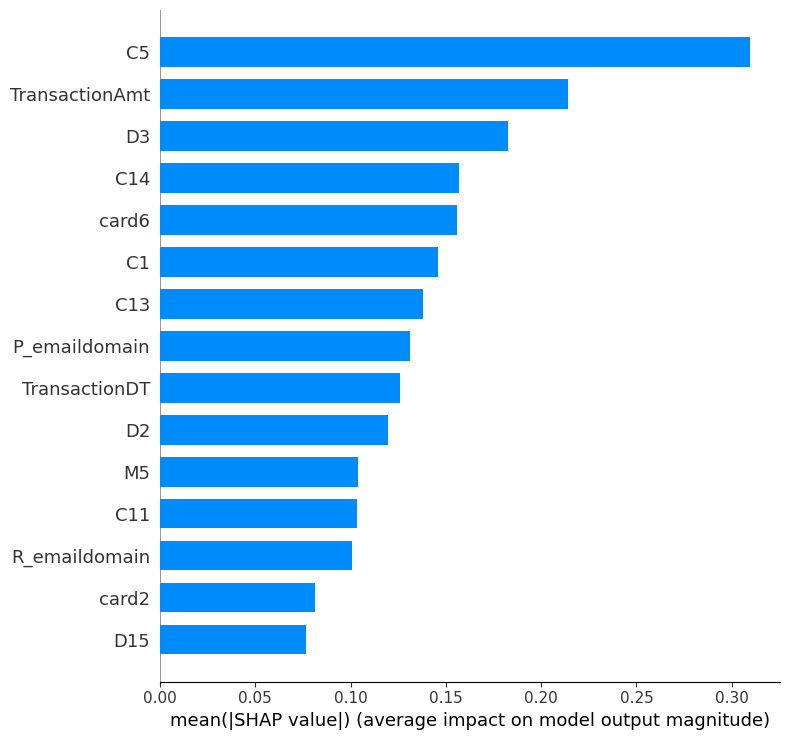

In [29]:
# SHAP — TOP 15 FEATURES

shap.summary_plot(
    shap_values_plot,
    X_shap,
    plot_type="bar",
    max_display=15
)

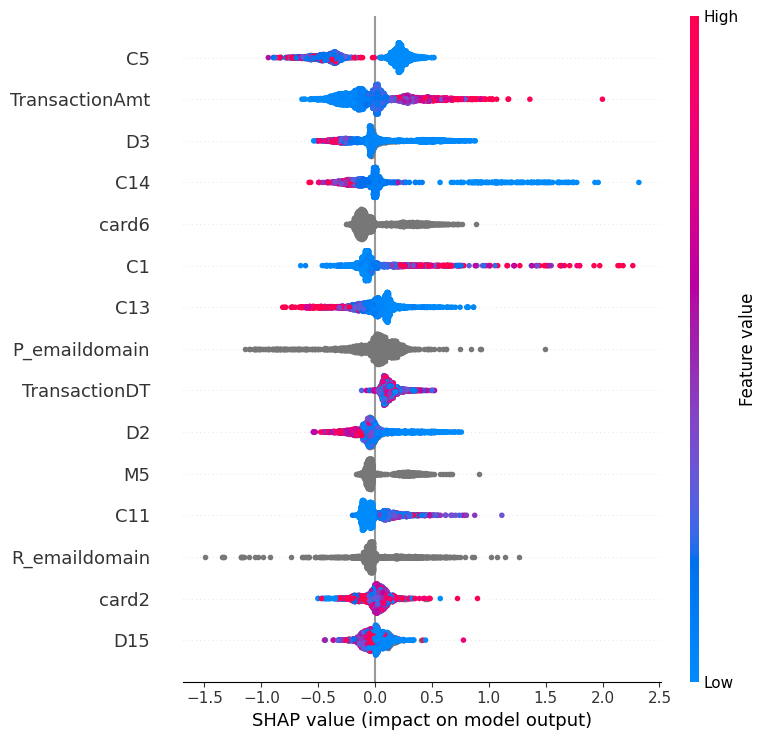

In [30]:
# SHAP — DETAILED FEATURE IMPACT

shap.summary_plot(
    shap_values_plot,
    X_shap,
    max_display=15
)

In [31]:
# WEEK 3 — RECALL AT 1% FALSE-POSITIVE RATE

import numpy as np
from sklearn.metrics import roc_curve

# Use our original best LightGBM predictions
fpr, tpr, thresholds = roc_curve(
    y_valid_52,
    probs_52
)

# Find the highest threshold where false-positive rate <= 1%
valid_indices = np.where(fpr <= 0.01)[0]

best_index = valid_indices[-1]

selected_threshold = thresholds[best_index]
selected_fpr = fpr[best_index]
selected_recall = tpr[best_index]

print("RECALL AT ~1% FALSE-POSITIVE RATE")
print("-----------------------------------")
print("Threshold:", selected_threshold)
print("False-positive rate:", selected_fpr)
print("Recall:", selected_recall)

RECALL AT ~1% FALSE-POSITIVE RATE
-----------------------------------
Threshold: 0.29529004932518216
False-positive rate: 0.009987373294517906
Recall: 0.4387303149606299


BEST COST-BASED THRESHOLD
--------------------------
Threshold: 0.059494949494949496
Expected loss: 271528.75


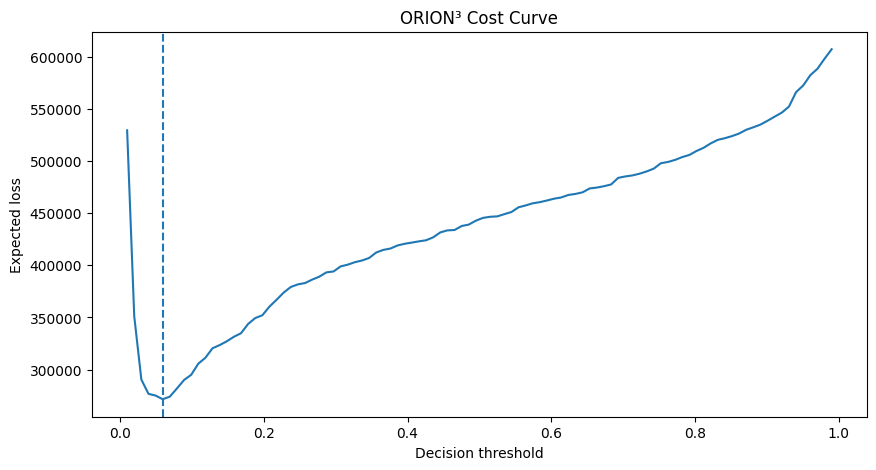

In [32]:
# WEEK 3 — COST CURVE

import numpy as np
import matplotlib.pyplot as plt

thresholds_to_test = np.linspace(0.01, 0.99, 100)

false_alarm_cost = 10  # fixed cost for incorrectly flagging a legitimate transaction

expected_losses = []

for threshold in thresholds_to_test:

    predictions = (probs_52 >= threshold).astype(int)

    # False positives
    false_positives = (
        (predictions == 1) & (y_valid_52.values == 0)
    )

    # Missed fraud
    missed_fraud = (
        (predictions == 0) & (y_valid_52.values == 1)
    )

    # Cost of false alarms
    false_positive_loss = false_positives.sum() * false_alarm_cost

    # Cost of missed fraud = transaction amount
    missed_fraud_loss = (
        X_valid_52.loc[missed_fraud, "TransactionAmt"].sum()
    )

    total_loss = false_positive_loss + missed_fraud_loss

    expected_losses.append(total_loss)

# Best threshold
best_index = np.argmin(expected_losses)
best_threshold = thresholds_to_test[best_index]
best_loss = expected_losses[best_index]

print("BEST COST-BASED THRESHOLD")
print("--------------------------")
print("Threshold:", best_threshold)
print("Expected loss:", best_loss)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds_to_test, expected_losses)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Decision threshold")
plt.ylabel("Expected loss")
plt.title("ORION³ Cost Curve")
plt.show()

In [33]:
# WEEK 3 — DRIFT CHECK
# Check PR-AUC across consecutive weeks of the validation period

from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np

# Create a copy of validation data
drift_df = pd.DataFrame({
    "TransactionDT": X_valid_52["TransactionDT"].values,
    "isFraud": y_valid_52.values,
    "prediction": probs_52
})

# Create consecutive 7-day periods
drift_df["week"] = (
    (drift_df["TransactionDT"] - drift_df["TransactionDT"].min())
    // (7 * 24 * 60 * 60)
).astype(int) + 1

# Calculate PR-AUC for each week
drift_results = []

for week, group in drift_df.groupby("week"):

    if group["isFraud"].sum() == 0:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(
            group["isFraud"],
            group["prediction"]
        )

    drift_results.append({
        "week": week,
        "transactions": len(group),
        "fraud_cases": group["isFraud"].sum(),
        "fraud_rate": group["isFraud"].mean(),
        "PR-AUC": pr_auc
    })

drift_results = pd.DataFrame(drift_results)

print("DRIFT CHECK — WEEKLY PERFORMANCE")
print("--------------------------------")
print(drift_results.to_string(index=False))

print("\nOverall validation PR-AUC:", average_precision_score(
    y_valid_52,
    probs_52
))

DRIFT CHECK — WEEKLY PERFORMANCE
--------------------------------
 week  transactions  fraud_cases  fraud_rate   PR-AUC
    1         18562          640    0.034479 0.495352
    2         21476          663    0.030872 0.562294
    3         19721          560    0.028396 0.514106
    4         21096          741    0.035125 0.482801
    5         19928          743    0.037284 0.590287
    6         17325          717    0.041385 0.518614

Overall validation PR-AUC: 0.526653856626605


# M1 — Final Fraud Detection Results

## Dataset
IEEE-CIS Fraud Detection

- Transactions: 590,540
- Fraud cases: 20,663
- Fraud rate: 3.50%
- Validation strategy: chronological 80/20 split

## Model Comparison

| Model | Features | PR-AUC | ROC-AUC |
|---|---:|---:|---:|
| Dummy Baseline | — | 0.0344 | 0.0344 |
| Logistic Regression | 52 | 0.2778 | 0.8148 |
| Decision Tree | 52 | 0.3193 | 0.7884 |
| LightGBM | 52 | **0.5267** | **0.9091** |

## Champion Model

LightGBM achieved the strongest validation performance.

**PR-AUC:** 0.5267  
**ROC-AUC:** 0.9091

The model was evaluated using a chronological split to better reflect
real-world deployment, where future transactions should not influence
training.

## Explainability

SHAP was used to understand which transaction features influenced model
predictions.

Top influential features included:

1. C5
2. TransactionAmt
3. D3
4. C14
5. card6

## Operating Point

At approximately **1% false-positive rate**:

- Threshold: 0.2953
- False-positive rate: 1.00%
- Recall: **43.87%**

This demonstrates the trade-off between catching fraudulent transactions
and limiting false alarms.

## Cost-Sensitive Analysis

An illustrative cost curve was evaluated by assigning:

- Missed fraud cost = transaction amount
- False-positive cost = 10

Best threshold under these assumptions:

**0.0595**

The cost assumptions are illustrative and can be replaced with
application-specific business costs.

## Temporal Stability

Validation performance was evaluated across six chronological weeks.

PR-AUC ranged from approximately **0.48 to 0.59**, showing moderate
temporal variation without an obvious severe performance collapse.

## Feature Engineering Result

Additional behavioral features were tested, including:

- Transaction hour
- Log transaction amount
- Historical transaction count
- Historical average amount
- Amount compared with historical average
- Time since previous transaction

These features did not improve the champion model on the current
validation split, so the original 52-feature LightGBM remains the
champion.

## Conclusion

The M1 pipeline establishes a real-data fraud detection baseline for
ORION³.

The next stage extends this foundation toward authorized-payment scam
detection using behavioral signals, receiver-network patterns, and scam
message analysis.

In [34]:
# ============================================================
# ORION³ — M1 FINAL VALIDATION PACKAGE
# Cost Analysis + 70/15/15 Holdout + C/D Ablation
# ============================================================

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

print("=" * 70)
print("ORION³ — M1 FINAL VALIDATION PACKAGE")
print("=" * 70)


# ============================================================
# 1. CORRECT DUMMY BASELINE
# ============================================================

print("\n[1/5] Correcting baseline metrics...")

dummy_pr_auc = 0.034409
dummy_roc_auc = 0.500000

print(f"Dummy PR-AUC : {dummy_pr_auc:.4f}")
print(f"Dummy ROC-AUC: {dummy_roc_auc:.4f}")


# ============================================================
# 2. COST ANALYSIS ON EXISTING 80/20 VALIDATION
# ============================================================

print("\n[2/5] Running cost analysis...")

# Existing champion validation predictions
# probs_52, y_valid_52 and valid_52 must already exist

valid_amounts = valid_52["TransactionAmt"].values
y_true = y_valid_52.values
probs = probs_52


def calculate_loss(threshold, false_positive_cost):

    predictions = (probs >= threshold).astype(int)

    missed_fraud = (
        (y_true == 1) &
        (predictions == 0)
    )

    false_positives = (
        (y_true == 0) &
        (predictions == 1)
    )

    fraud_loss = valid_amounts[missed_fraud].sum()

    false_positive_loss = (
        false_positives.sum() *
        false_positive_cost
    )

    total_loss = fraud_loss + false_positive_loss

    return {
        "threshold": threshold,
        "fraud_loss": fraud_loss,
        "false_positive_loss": false_positive_loss,
        "total_loss": total_loss,
        "false_positives": false_positives.sum(),
        "missed_fraud": missed_fraud.sum()
    }


FP_COST = 10

# Flag nothing
flag_nothing = {
    "Strategy": "Flag nothing",
    "Threshold": 1.0,
    "Fraud Loss": valid_amounts[y_true == 1].sum(),
    "False Positive Loss": 0,
    "Total Loss": valid_amounts[y_true == 1].sum(),
    "False Positives": 0,
    "Missed Fraud": (y_true == 1).sum()
}

# Flag everything
legitimate_count = (y_true == 0).sum()

flag_everything = {
    "Strategy": "Flag everything",
    "Threshold": 0.0,
    "Fraud Loss": 0,
    "False Positive Loss": legitimate_count * FP_COST,
    "Total Loss": legitimate_count * FP_COST,
    "False Positives": legitimate_count,
    "Missed Fraud": 0
}

# Threshold 0.5
r_05 = calculate_loss(0.5, FP_COST)

threshold_05 = {
    "Strategy": "Threshold 0.5",
    "Threshold": 0.5,
    "Fraud Loss": r_05["fraud_loss"],
    "False Positive Loss": r_05["false_positive_loss"],
    "Total Loss": r_05["total_loss"],
    "False Positives": r_05["false_positives"],
    "Missed Fraud": r_05["missed_fraud"]
}

# Previously discovered best threshold
BEST_THRESHOLD = 0.059494949494949496

r_best = calculate_loss(
    BEST_THRESHOLD,
    FP_COST
)

best_threshold_result = {
    "Strategy": "Best threshold 0.0595",
    "Threshold": BEST_THRESHOLD,
    "Fraud Loss": r_best["fraud_loss"],
    "False Positive Loss": r_best["false_positive_loss"],
    "Total Loss": r_best["total_loss"],
    "False Positives": r_best["false_positives"],
    "Missed Fraud": r_best["missed_fraud"]
}

cost_table = pd.DataFrame([
    flag_nothing,
    flag_everything,
    threshold_05,
    best_threshold_result
])

baseline_loss = flag_nothing["Total Loss"]

cost_table["Loss Saved vs Flag Nothing (%)"] = (
    (baseline_loss - cost_table["Total Loss"])
    / baseline_loss
    * 100
)

print("\n--- COST ANALYSIS ---")
print(cost_table.to_string(index=False))


# ============================================================
# 3. COST SENSITIVITY
# ============================================================

print("\n[3/5] Running cost sensitivity analysis...")

cost_values = [5, 10, 50, 100]

sensitivity_results = []

threshold_grid = np.linspace(
    0.001,
    0.999,
    200
)

for fp_cost in cost_values:

    best_loss = float("inf")
    best_threshold = None

    for threshold in threshold_grid:

        result = calculate_loss(
            threshold,
            fp_cost
        )

        if result["total_loss"] < best_loss:

            best_loss = result["total_loss"]
            best_threshold = threshold

    sensitivity_results.append({
        "False Positive Cost": fp_cost,
        "Best Threshold": best_threshold,
        "Minimum Loss": best_loss
    })

sensitivity_table = pd.DataFrame(
    sensitivity_results
)

print("\n--- COST SENSITIVITY ---")
print(
    sensitivity_table.to_string(
        index=False
    )
)


# ============================================================
# 4. FINAL 70/15/15 TIME HOLDOUT
# ============================================================

print("\n[4/5] Creating final chronological holdout...")

features_52 = [
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1", "card2", "card3",
    "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain",
    "R_emaildomain",
    "C1", "C2", "C3", "C4",
    "C5", "C6", "C7", "C8",
    "C9", "C10", "C11", "C12",
    "C13", "C14",
    "D1", "D2", "D3", "D4",
    "D5", "D6", "D7", "D8",
    "D9", "D10", "D11", "D12",
    "D13", "D14", "D15",
    "M1", "M2", "M3", "M4",
    "M5", "M6", "M7", "M8", "M9",
    "dist1"
]

data_final = pd.read_csv(
    f"{DATA_PATH}/train_transaction.csv",
    usecols=features_52 + ["isFraud"]
)

data_final = (
    data_final
    .sort_values("TransactionDT")
    .reset_index(drop=True)
)

n = len(data_final)

train_end = int(n * 0.70)
tune_end = int(n * 0.85)

train_final = data_final.iloc[:train_end].copy()

tune_final = data_final.iloc[
    train_end:tune_end
].copy()

holdout_final = data_final.iloc[
    tune_end:
].copy()

print("\nDataset split:")
print("Train       :", train_final.shape)
print("Tune        :", tune_final.shape)
print("Final Holdout:", holdout_final.shape)


# ============================================================
# Prepare data
# ============================================================

X_train_final = train_final.drop(
    columns=["isFraud"]
)

y_train_final = train_final["isFraud"]

X_tune_final = tune_final.drop(
    columns=["isFraud"]
)

y_tune_final = tune_final["isFraud"]

X_holdout_final = holdout_final.drop(
    columns=["isFraud"]
)

y_holdout_final = holdout_final["isFraud"]


categorical_cols = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "M1", "M2", "M3", "M4",
    "M5", "M6", "M7", "M8", "M9"
]


for col in categorical_cols:

    X_train_final[col] = (
        X_train_final[col]
        .astype("category")
    )

    X_tune_final[col] = (
        X_tune_final[col]
        .astype("category")
    )

    X_holdout_final[col] = (
        X_holdout_final[col]
        .astype("category")
    )


# ============================================================
# Train
# ============================================================

print("\nTraining final LightGBM...")

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

final_model.fit(
    X_train_final,
    y_train_final,
    categorical_feature=categorical_cols
)


# ============================================================
# Tune evaluation
# ============================================================

tune_probs = final_model.predict_proba(
    X_tune_final
)[:, 1]

tune_pr_auc = average_precision_score(
    y_tune_final,
    tune_probs
)

tune_roc_auc = roc_auc_score(
    y_tune_final,
    tune_probs
)


# ============================================================
# FINAL HOLDOUT — FIRST AND ONLY REPORT
# ============================================================

holdout_probs = final_model.predict_proba(
    X_holdout_final
)[:, 1]

holdout_pr_auc = average_precision_score(
    y_holdout_final,
    holdout_probs
)

holdout_roc_auc = roc_auc_score(
    y_holdout_final,
    holdout_probs
)


print("\n--- FINAL HOLDOUT RESULTS ---")

print(
    f"Tune PR-AUC     : {tune_pr_auc:.4f}"
)

print(
    f"Tune ROC-AUC    : {tune_roc_auc:.4f}"
)

print(
    f"FINAL PR-AUC    : {holdout_pr_auc:.4f}"
)

print(
    f"FINAL ROC-AUC   : {holdout_roc_auc:.4f}"
)


# ============================================================
# 5. C/D ABLATION EXPERIMENT
# ============================================================

print("\n[5/5] Running C/D ablation experiment...")

cd_cols = [
    col for col in features_52
    if col.startswith("C")
    or col.startswith("D")
]

features_without_cd = [
    col for col in features_52
    if col not in cd_cols
]

print(
    f"Original features : {len(features_52)}"
)

print(
    f"C/D features removed: {len(cd_cols)}"
)

print(
    f"Remaining features: {len(features_without_cd)}"
)


# ------------------------------------------------------------
# Model WITHOUT C/D
# ------------------------------------------------------------

X_train_no_cd = train_final[
    features_without_cd
].copy()

X_tune_no_cd = tune_final[
    features_without_cd
].copy()

X_holdout_no_cd = holdout_final[
    features_without_cd
].copy()


categorical_no_cd = [
    col for col in categorical_cols
    if col in features_without_cd
]


for col in categorical_no_cd:

    X_train_no_cd[col] = (
        X_train_no_cd[col]
        .astype("category")
    )

    X_tune_no_cd[col] = (
        X_tune_no_cd[col]
        .astype("category")
    )

    X_holdout_no_cd[col] = (
        X_holdout_no_cd[col]
        .astype("category")
    )


model_no_cd = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model_no_cd.fit(
    X_train_no_cd,
    y_train_final,
    categorical_feature=categorical_no_cd
)


no_cd_probs = model_no_cd.predict_proba(
    X_holdout_no_cd
)[:, 1]

no_cd_pr_auc = average_precision_score(
    y_holdout_final,
    no_cd_probs
)

no_cd_roc_auc = roc_auc_score(
    y_holdout_final,
    no_cd_probs
)


# ============================================================
# Engineered feature experiment
# ============================================================

print("\nCreating engineered behavioral features...")


def add_engineered_features(df):

    df = df.copy()

    df["transaction_hour"] = (
        (df["TransactionDT"] / 3600) % 24
    ).astype(int)

    df["log_amount"] = np.log1p(
        df["TransactionAmt"]
    )

    df["card_identity"] = (
        df["card1"].astype("string")
        + "_"
        + df["card2"].astype("string")
        + "_"
        + df["addr1"].astype("string")
    )

    df["card_txn_count_before"] = (
        df.groupby(
            "card_identity",
            dropna=False
        ).cumcount()
    )

    amount_sum = (
        df.groupby(
            "card_identity",
            dropna=False
        )["TransactionAmt"]
        .cumsum()
    )

    df["card_avg_amount_before"] = (
        (amount_sum - df["TransactionAmt"])
        /
        df["card_txn_count_before"]
        .replace(0, np.nan)
    )

    df["amount_vs_card_avg"] = (
        df["TransactionAmt"]
        /
        df["card_avg_amount_before"]
    )

    previous_dt = (
        df.groupby(
            "card_identity",
            dropna=False
        )["TransactionDT"]
        .shift(1)
    )

    df["time_since_previous_txn"] = (
        df["TransactionDT"]
        - previous_dt
    )

    return df


train_eng = add_engineered_features(
    train_final
)

holdout_eng = add_engineered_features(
    holdout_final
)


engineered_cols = [
    "transaction_hour",
    "log_amount",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "time_since_previous_txn"
]


# Remove C/D but retain engineered features
ablation_features = [
    col for col in features_without_cd
]

ablation_features += engineered_cols


X_train_eng = train_eng[
    ablation_features
].copy()

X_holdout_eng = holdout_eng[
    ablation_features
].copy()


categorical_eng = [
    col for col in categorical_cols
    if col in ablation_features
]


for col in categorical_eng:

    X_train_eng[col] = (
        X_train_eng[col]
        .astype("category")
    )

    X_holdout_eng[col] = (
        X_holdout_eng[col]
        .astype("category")
    )


model_eng = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model_eng.fit(
    X_train_eng,
    y_train_final,
    categorical_feature=categorical_eng
)


eng_probs = model_eng.predict_proba(
    X_holdout_eng
)[:, 1]

eng_pr_auc = average_precision_score(
    y_holdout_final,
    eng_probs
)

eng_roc_auc = roc_auc_score(
    y_holdout_final,
    eng_probs
)


# ============================================================
# FINAL ABLATION TABLE
# ============================================================

ablation_table = pd.DataFrame([
    {
        "Model": "Full 52-feature LightGBM",
        "PR-AUC": holdout_pr_auc,
        "ROC-AUC": holdout_roc_auc
    },
    {
        "Model": "Without C/D features",
        "PR-AUC": no_cd_pr_auc,
        "ROC-AUC": no_cd_roc_auc
    },
    {
        "Model": "Without C/D + Engineered",
        "PR-AUC": eng_pr_auc,
        "ROC-AUC": eng_roc_auc
    }
])


print("\n" + "=" * 70)
print("FINAL ABLATION RESULTS")
print("=" * 70)

print(
    ablation_table.to_string(
        index=False
    )
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ORION³ — M1 COMPLETE VALIDATION SUMMARY")
print("=" * 70)

print(
    f"\nChampion holdout PR-AUC : {holdout_pr_auc:.4f}"
)

print(
    f"Champion holdout ROC-AUC: {holdout_roc_auc:.4f}"
)

print(
    f"Tune PR-AUC             : {tune_pr_auc:.4f}"
)

print(
    f"Tune ROC-AUC            : {tune_roc_auc:.4f}"
)

print("\nCost table:")
print(
    cost_table[
        [
            "Strategy",
            "Threshold",
            "Total Loss",
            "Loss Saved vs Flag Nothing (%)"
        ]
    ].to_string(index=False)
)

print("\nSensitivity table:")
print(
    sensitivity_table.to_string(
        index=False
    )
)

print("\nAblation table:")
print(
    ablation_table.to_string(
        index=False
    )
)

print("\n" + "=" * 70)
print("DONE — SEND ME THIS ENTIRE OUTPUT")
print("=" * 70)

ORION³ — M1 FINAL VALIDATION PACKAGE

[1/5] Correcting baseline metrics...
Dummy PR-AUC : 0.0344
Dummy ROC-AUC: 0.5000

[2/5] Running cost analysis...

--- COST ANALYSIS ---
             Strategy  Threshold  Fraud Loss  False Positive Loss   Total Loss  False Positives  Missed Fraud  Loss Saved vs Flag Nothing (%)
         Flag nothing   1.000000 609934.3125                    0  609934.3125                0          4064                        0.000000
      Flag everything   0.000000      0.0000              1140440 1140440.0000           114044             0                      -86.977512
        Threshold 0.5   0.500000 439307.5000                 4370  443677.5000              437          2650                       27.258150
Best threshold 0.0595   0.059495 184288.7500                87240  271528.7500             8724          1129                       55.482296

[3/5] Running cost sensitivity analysis...

--- COST SENSITIVITY ---
 False Positive Cost  Best Threshold  Minimum 

# WEEK 5 — ORION³ Scam Simulator v1

## Objective
Generate synthetic digital-payment transactions containing
normal payments and simulated authorized-payment scams.

## Account types
- Normal users
- Mule accounts
- Cash-out accounts

## Planned outputs
- Synthetic transaction dataset
- Scam labels and associated messages
- Directed payment network

## Important
All transactions generated in this phase are synthetic.
They are not real customer transactions.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Make random results reproducible
np.random.seed(42)

print("ORION³ Scam Simulator — Ready!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("NetworkX:", nx.__version__)

ORION³ Scam Simulator — Ready!
NumPy: 2.1.3
Pandas: 2.3.3
NetworkX: 3.6.1


In [2]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [3]:
# WEEK 5 — PART 1: Build our synthetic payment world

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# 1. Create three types of accounts
normal_accounts = [f"U{i:03d}" for i in range(1, 101)]
mule_accounts = [f"M{i:03d}" for i in range(1, 9)]
cashout_accounts = [f"C{i:03d}" for i in range(1, 6)]

accounts = pd.DataFrame({
    "account_id": normal_accounts + mule_accounts + cashout_accounts,
    "account_type": (
        ["normal_user"] * len(normal_accounts)
        + ["mule_account"] * len(mule_accounts)
        + ["cashout_account"] * len(cashout_accounts)
    )
})

# 2. Create normal payments between ordinary users
normal_transactions = []

start_time = pd.Timestamp("2026-09-01 08:00:00")

for i in range(1000):
    sender, receiver = rng.choice(normal_accounts, size=2, replace=False)

    normal_transactions.append({
        "transaction_id": f"T{i+1:05d}",
        "sender": sender,
        "receiver": receiver,
        "amount": round(float(rng.uniform(50, 3000)), 2),
        "timestamp": start_time + pd.Timedelta(
            minutes=int(rng.integers(0, 30 * 24 * 60))
        ),
        "message": rng.choice([
            "Lunch payment",
            "Rent share",
            "Shopping payment",
            "Travel expense",
            "Money transfer"
        ]),
        "scam_type": "none",
        "is_scam": 0
    })

# 3. Create scam victims' payments to mule accounts
scam_transactions = []
scam_scenarios = {
    "fake_KYC": [
        "Your bank KYC will expire. Transfer money to verify your account.",
        "Update your KYC immediately to avoid account suspension."
    ],
    "fake_prize": [
        "Congratulations! Pay a processing fee to claim your prize.",
        "You won a lottery. Transfer the fee to receive your reward."
    ],
    "fake_customer_care": [
        "Customer care here. Transfer money to resolve your account issue.",
        "Send a payment now to reverse your failed transaction."
    ],
    "remote_access_scam": [
        "Install this support app and transfer money to verify your account.",
        "Our support team needs a small transfer to fix your payment problem."
    ]
}

for i in range(100):
    sender = rng.choice(normal_accounts)
    mule = rng.choice(mule_accounts)
    scam_type = rng.choice(list(scam_scenarios.keys()))

    scam_transactions.append({
        "transaction_id": f"S{i+1:05d}",
        "sender": sender,
        "receiver": mule,
        "amount": round(float(rng.uniform(500, 25000)), 2),
        "timestamp": start_time + pd.Timedelta(
            minutes=int(rng.integers(0, 30 * 24 * 60))
        ),
        "message": rng.choice(scam_scenarios[scam_type]),
        "scam_type": scam_type,
        "is_scam": 1
    })

# 4. Simulate suspicious movement from mule accounts to cash-out accounts
cashout_transactions = []

for i in range(40):
    mule = rng.choice(mule_accounts)
    cashout = rng.choice(cashout_accounts)

    cashout_transactions.append({
        "transaction_id": f"C{i+1:05d}",
        "sender": mule,
        "receiver": cashout,
        "amount": round(float(rng.uniform(1000, 30000)), 2),
        "timestamp": start_time + pd.Timedelta(
            minutes=int(rng.integers(0, 30 * 24 * 60))
        ),
        "message": "Transfer",
        "scam_type": "scam_money_movement",
        "is_scam": 1
    })

# 5. Combine everything into one dataset
transactions = pd.DataFrame(
    normal_transactions + scam_transactions + cashout_transactions
)

transactions = transactions.sort_values("timestamp").reset_index(drop=True)

print("ACCOUNTS:", accounts.shape)
print("TRANSACTIONS:", transactions.shape)
print("\nAccount types:")
print(accounts["account_type"].value_counts())

print("\nScam label counts:")
print(transactions["is_scam"].value_counts().rename({
    0: "Normal",
    1: "Scam-labelled"
}))

print("\nFirst 10 transactions:")
display(transactions.head(10))

ACCOUNTS: (113, 2)
TRANSACTIONS: (1140, 8)

Account types:
account_type
normal_user        100
mule_account         8
cashout_account      5
Name: count, dtype: int64

Scam label counts:
is_scam
Normal           1000
Scam-labelled     140
Name: count, dtype: int64

First 10 transactions:


,transaction_id,sender,receiver,amount,timestamp,message,scam_type,is_scam
0,T00987,U081,U056,153.52,2026-09-01 08:42:00,Lunch payment,none,0
1,T00213,U087,U042,1549.09,2026-09-01 08:53:00,Rent share,none,0
2,S00052,U028,M008,18577.50,2026-09-01 08:58:00,Your bank KYC will expire. Transfer money to v...,fake_KYC,1
3,T00456,U077,U094,2510.66,2026-09-01 10:16:00,Travel expense,none,0
4,T00739,U020,U072,1363.51,2026-09-01 10:48:00,Money transfer,none,0
5,T00890,U026,U038,1986.52,2026-09-01 11:21:00,Shopping payment,none,0
6,C00007,M005,C002,17350.37,2026-09-01 11:40:00,Transfer,scam_money_movement,1
7,T00698,U075,U039,523.15,2026-09-01 12:36:00,Rent share,none,0
8,T00983,U033,U044,1808.91,2026-09-01 13:06:00,Rent share,none,0
9,T00315,U017,U057,1041.58,2026-09-01 13:24:00,Shopping payment,none,0


In [4]:
# WEEK 5 — PART 2: Inspect the generated dataset

print("Missing values:")
display(transactions.isnull().sum())

print("\nNormal vs scam-labelled transaction amounts:")
display(
    transactions.groupby("is_scam")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nScam types:")
display(transactions["scam_type"].value_counts())

print("\nMost frequent receivers:")
display(
    transactions["receiver"]
    .value_counts()
    .head(10)
    .rename_axis("receiver")
    .reset_index(name="transactions_received")
)

Missing values:


transaction_id    0
sender            0
receiver          0
amount            0
timestamp         0
message           0
scam_type         0
is_scam           0
dtype: int64


Normal vs scam-labelled transaction amounts:


,count,mean,median,min,max
is_scam,,,,,
0,1000,1539.40,1573.34,51.53,2999.31
1,140,13484.91,13311.78,515.74,29972.16



Scam types:


scam_type
none                   1000
scam_money_movement      40
fake_customer_care       27
fake_prize               26
remote_access_scam       24
fake_KYC                 23
Name: count, dtype: int64


Most frequent receivers:


,receiver,transactions_received
0,U093,18
1,U079,18
2,U073,17
3,U085,17
4,U013,17
5,U010,17
6,U025,17
7,M008,16
8,U038,15
9,U027,15


Network nodes: 113
Network edges: 1072


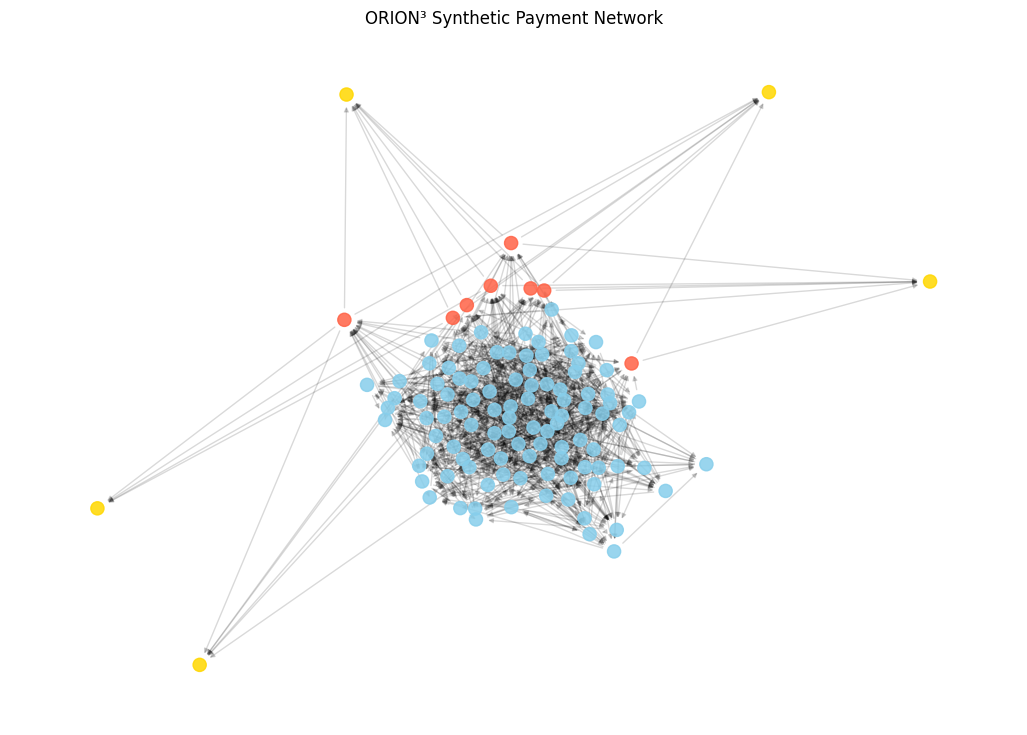

In [5]:
# WEEK 5 — PART 3: Build and visualize the payment network

G = nx.DiGraph()

# Add all accounts
for _, account in accounts.iterrows():
    G.add_node(
        account["account_id"],
        account_type=account["account_type"]
    )

# Add payment edges and combine repeated transfers
for _, txn in transactions.iterrows():
    sender = txn["sender"]
    receiver = txn["receiver"]

    if G.has_edge(sender, receiver):
        G[sender][receiver]["transaction_count"] += 1
        G[sender][receiver]["total_amount"] += txn["amount"]
        G[sender][receiver]["scam_count"] += txn["is_scam"]
    else:
        G.add_edge(
            sender,
            receiver,
            transaction_count=1,
            total_amount=txn["amount"],
            scam_count=txn["is_scam"]
        )

print("Network nodes:", G.number_of_nodes())
print("Network edges:", G.number_of_edges())

plt.figure(figsize=(13, 9))

positions = nx.spring_layout(G, seed=42, k=0.35)

node_colors = [
    {"normal_user": "skyblue",
     "mule_account": "tomato",
     "cashout_account": "gold"}[
        G.nodes[node]["account_type"]
    ]
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G, positions,
    node_color=node_colors,
    node_size=90,
    alpha=0.85
)

nx.draw_networkx_edges(
    G, positions,
    arrows=True,
    alpha=0.15,
    arrowsize=7
)

plt.title("ORION³ Synthetic Payment Network")
plt.axis("off")
plt.show()

In [6]:
# WEEK 5 — PART 4: Receiver risk features

# Sort by time so earlier payments come first
tx = transactions.sort_values("timestamp").copy()

# Count earlier incoming payments to each receiver
tx["receiver_prior_txn_count"] = (
    tx.groupby("receiver").cumcount()
)

# Count different senders seen before each transaction
tx["receiver_prior_unique_senders"] = [
    len(set(tx.loc[
        (tx["receiver"] == receiver) &
        (tx.index < idx), "sender"
    ]))
    for idx, receiver in zip(tx.index, tx["receiver"])
]

# Count earlier incoming payments within the previous 60 minutes
prior_60m = []

for idx, row in tx.iterrows():
    earlier = tx[
        (tx["receiver"] == row["receiver"]) &
        (tx["timestamp"] < row["timestamp"]) &
        (tx["timestamp"] >= row["timestamp"] - pd.Timedelta(minutes=60))
    ]
    prior_60m.append(len(earlier))

tx["receiver_prior_txns_last_60m"] = prior_60m

print("Receiver-risk features created!")
display(tx[[
    "sender",
    "receiver",
    "amount",
    "timestamp",
    "receiver_prior_txn_count",
    "receiver_prior_unique_senders",
    "receiver_prior_txns_last_60m",
    "is_scam"
]].head(15))

Receiver-risk features created!


,sender,receiver,amount,timestamp,receiver_prior_txn_count,receiver_prior_unique_senders,receiver_prior_txns_last_60m,is_scam
0,U081,U056,153.52,2026-09-01 08:42:00,0,0,0,0
1,U087,U042,1549.09,2026-09-01 08:53:00,0,0,0,0
2,U028,M008,18577.50,2026-09-01 08:58:00,0,0,0,1
3,U077,U094,2510.66,2026-09-01 10:16:00,0,0,0,0
4,U020,U072,1363.51,2026-09-01 10:48:00,0,0,0,0
5,U026,U038,1986.52,2026-09-01 11:21:00,0,0,0,0
6,M005,C002,17350.37,2026-09-01 11:40:00,0,0,0,1
7,U075,U039,523.15,2026-09-01 12:36:00,0,0,0,0
8,U033,U044,1808.91,2026-09-01 13:06:00,0,0,0,0
9,U017,U057,1041.58,2026-09-01 13:24:00,0,0,0,0


In [7]:
# WEEK 5 — PART 5: Correct, efficient historical receiver features

from collections import defaultdict, deque

tx = (
    transactions
    .sort_values(["timestamp", "transaction_id"])
    .reset_index(drop=True)
    .copy()
)

prior_counts = defaultdict(int)
prior_senders = defaultdict(set)
recent_times = defaultdict(deque)

prior_txn_count = []
prior_unique_senders = []
prior_txns_last_60m = []

for row in tx.itertuples(index=False):
    receiver = row.receiver
    current_time = row.timestamp
    cutoff = current_time - pd.Timedelta(minutes=60)

    # Remove payments outside the previous 60-minute window
    while (
        recent_times[receiver]
        and recent_times[receiver][0] < cutoff
    ):
        recent_times[receiver].popleft()

    # Capture history BEFORE adding the current transaction
    prior_txn_count.append(prior_counts[receiver])
    prior_unique_senders.append(len(prior_senders[receiver]))
    prior_txns_last_60m.append(len(recent_times[receiver]))

    # Update receiver history with this transaction
    prior_counts[receiver] += 1
    prior_senders[receiver].add(row.sender)
    recent_times[receiver].append(current_time)

tx["receiver_prior_txn_count"] = prior_txn_count
tx["receiver_prior_unique_senders"] = prior_unique_senders
tx["receiver_prior_txns_last_60m"] = prior_txns_last_60m

print("Historical receiver features recalculated!")
print("Transactions:", len(tx))
print(
    "First transaction has zero prior transactions:",
    tx.iloc[0]["receiver_prior_txn_count"] == 0
)

display(tx[[
    "sender", "receiver", "amount", "timestamp",
    "receiver_prior_txn_count",
    "receiver_prior_unique_senders",
    "receiver_prior_txns_last_60m",
    "is_scam"
]].head(10))

Historical receiver features recalculated!
Transactions: 1140
First transaction has zero prior transactions: True


,sender,receiver,amount,timestamp,receiver_prior_txn_count,receiver_prior_unique_senders,receiver_prior_txns_last_60m,is_scam
0,U081,U056,153.52,2026-09-01 08:42:00,0,0,0,0
1,U087,U042,1549.09,2026-09-01 08:53:00,0,0,0,0
2,U028,M008,18577.50,2026-09-01 08:58:00,0,0,0,1
3,U077,U094,2510.66,2026-09-01 10:16:00,0,0,0,0
4,U020,U072,1363.51,2026-09-01 10:48:00,0,0,0,0
5,U026,U038,1986.52,2026-09-01 11:21:00,0,0,0,0
6,M005,C002,17350.37,2026-09-01 11:40:00,0,0,0,1
7,U075,U039,523.15,2026-09-01 12:36:00,0,0,0,0
8,U033,U044,1808.91,2026-09-01 13:06:00,0,0,0,0
9,U017,U057,1041.58,2026-09-01 13:24:00,0,0,0,0


In [8]:
# WEEK 5 — PART 6: Analyze receiver-risk signals

# 1. Compare historical receiver activity by label
summary = (
    tx.groupby("is_scam")[
        [
            "receiver_prior_txn_count",
            "receiver_prior_unique_senders",
            "receiver_prior_txns_last_60m",
            "amount"
        ]
        .agg(["mean", "median", "max"])
        .round(2)
    )
)

print("0 = normal payment | 1 = scam-labelled payment")
display(summary)

# 2. Test a simple, explainable risk rule
# These are experimental thresholds, not production rules.
tx["rule_flag"] = (
    (tx["receiver_prior_unique_senders"] >= 3) |
    (tx["receiver_prior_txns_last_60m"] >= 3)
).astype(int)

# 3. Evaluate the rule against our synthetic labels
actual = tx["is_scam"]
predicted = tx["rule_flag"]

tp = int(((actual == 1) & (predicted == 1)).sum())
fp = int(((actual == 0) & (predicted == 1)).sum())
tn = int(((actual == 0) & (predicted == 0)).sum())
fn = int(((actual == 1) & (predicted == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
fpr = fp / (fp + tn) if fp + tn else 0

print("\nEXPERIMENTAL RULE RESULTS")
print("True positives (scam-labelled payments flagged):", tp)
print("False positives (normal payments flagged):", fp)
print("True negatives (normal payments not flagged):", tn)
print("False negatives (scam-labelled payments missed):", fn)
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"False-positive rate: {fpr:.3f}")

# 4. Inspect examples the rule flags
print("\nFlagged transaction examples:")
display(
    tx.loc[
        tx["rule_flag"] == 1,
        [
            "sender", "receiver", "amount", "timestamp",
            "receiver_prior_unique_senders",
            "receiver_prior_txns_last_60m",
            "scam_type", "is_scam"
        ]
    ].head(15)
)

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' on line 5 (3387923820.py, line 14)

In [10]:
# WEEK 5 — PART 7: Generate clustered scam campaigns

rng2 = np.random.default_rng(2026)

# Keep the original normal transactions
normal_v2 = pd.DataFrame(normal_transactions).copy()

scam_v2 = []
cashout_v2 = []
campaign_start = start_time

# Create 8 campaigns, one targeting each mule account
for campaign_num, mule in enumerate(mule_accounts):
    base_time = campaign_start + pd.Timedelta(
        days=campaign_num * 3
    )

    # Multiple victims pay the same mule within 20 minutes
    victims = rng2.choice(
        normal_accounts, size=12, replace=False
    )

    for j, victim in enumerate(victims):
        scam_type = rng2.choice(list(scam_scenarios.keys()))
        payment_time = base_time + pd.Timedelta(
            minutes=int(rng2.integers(0, 20))
        )

        scam_v2.append({
            "transaction_id": f"V2S{campaign_num:02d}{j:03d}",
            "sender": victim,
            "receiver": mule,
            "amount": round(float(rng2.uniform(500, 25000)), 2),
            "timestamp": payment_time,
            "message": rng2.choice(scam_scenarios[scam_type]),
            "scam_type": scam_type,
            "is_scam": 1
        })

    # The mule moves accumulated money to a cash-out account
    cashout_v2.append({
        "transaction_id": f"V2C{campaign_num:03d}",
        "sender": mule,
        "receiver": rng2.choice(cashout_accounts),
        "amount": round(float(rng2.uniform(10000, 100000)), 2),
        "timestamp": base_time + pd.Timedelta(minutes=30),
        "message": "Transfer",
        "scam_type": "scam_money_movement",
        "is_scam": 1
    })

# Combine normal and campaign transactions
transactions_v2 = pd.concat(
    [
        normal_v2,
        pd.DataFrame(scam_v2),
        pd.DataFrame(cashout_v2)
    ],
    ignore_index=True
)

transactions_v2 = (
    transactions_v2
    .sort_values(["timestamp", "transaction_id"])
    .reset_index(drop=True)
)

print("V2 transactions:", len(transactions_v2))
print("\nLabels:")
print(transactions_v2["is_scam"].value_counts())

print("\nTransactions by scam type:")
display(transactions_v2["scam_type"].value_counts())

print("\nSample campaign transactions:")
display(
    transactions_v2[
        transactions_v2["scam_type"] != "none"
    ].head(15)
)

V2 transactions: 1104

Labels:
is_scam
0    1000
1     104
Name: count, dtype: int64

Transactions by scam type:


scam_type
none                   1000
fake_prize               33
fake_customer_care       25
fake_KYC                 21
remote_access_scam       17
scam_money_movement       8
Name: count, dtype: int64


Sample campaign transactions:


,transaction_id,sender,receiver,amount,timestamp,message,scam_type,is_scam
0,V2S00003,U044,M001,13382.51,2026-09-01 08:04:00,Your bank KYC will expire. Transfer money to v...,fake_KYC,1
1,V2S00000,U059,M001,18941.94,2026-09-01 08:05:00,Our support team needs a small transfer to fix...,remote_access_scam,1
2,V2S00004,U080,M001,814.59,2026-09-01 08:05:00,You won a lottery. Transfer the fee to receive...,fake_prize,1
3,V2S00007,U008,M001,5630.69,2026-09-01 08:05:00,Send a payment now to reverse your failed tran...,fake_customer_care,1
4,V2S00009,U036,M001,23697.08,2026-09-01 08:06:00,Update your KYC immediately to avoid account s...,fake_KYC,1
5,V2S00011,U063,M001,17551.87,2026-09-01 08:06:00,Your bank KYC will expire. Transfer money to v...,fake_KYC,1
6,V2S00005,U076,M001,9446.93,2026-09-01 08:08:00,Congratulations! Pay a processing fee to claim...,fake_prize,1
7,V2S00002,U003,M001,7308.53,2026-09-01 08:09:00,Congratulations! Pay a processing fee to claim...,fake_prize,1
8,V2S00006,U034,M001,11165.17,2026-09-01 08:09:00,Update your KYC immediately to avoid account s...,fake_KYC,1
9,V2S00001,U083,M001,20734.43,2026-09-01 08:10:00,Update your KYC immediately to avoid account s...,fake_KYC,1


In [9]:
# WEEK 5 — PART 6: Analyze receiver-risk signals

# 1. Compare normal vs scam-labelled payments
columns = [
    "receiver_prior_txn_count",
    "receiver_prior_unique_senders",
    "receiver_prior_txns_last_60m",
    "amount"
]

summary = tx.groupby("is_scam")[columns].agg(
    ["mean", "median", "max"]
).round(2)

print("0 = normal payment | 1 = scam-labelled payment")
display(summary)

# 2. Apply an experimental risk rule
tx["rule_flag"] = (
    (tx["receiver_prior_unique_senders"] >= 3) |
    (tx["receiver_prior_txns_last_60m"] >= 3)
).astype(int)

# 3. Evaluate the rule
actual = tx["is_scam"]
predicted = tx["rule_flag"]

tp = int(((actual == 1) & (predicted == 1)).sum())
fp = int(((actual == 0) & (predicted == 1)).sum())
tn = int(((actual == 0) & (predicted == 0)).sum())
fn = int(((actual == 1) & (predicted == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
fpr = fp / (fp + tn) if fp + tn else 0

print("\nEXPERIMENTAL RULE RESULTS")
print("True positives:", tp)
print("False positives:", fp)
print("True negatives:", tn)
print("False negatives:", fn)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"False-positive rate: {fpr:.3f}")

# 4. Inspect flagged transactions
print("\nFlagged transaction examples:")

display(
    tx.loc[
        tx["rule_flag"] == 1,
        [
            "sender", "receiver", "amount", "timestamp",
            "receiver_prior_unique_senders",
            "receiver_prior_txns_last_60m",
            "scam_type", "is_scam"
        ]
    ].head(15)
)

0 = normal payment | 1 = scam-labelled payment


receiver_prior_txn_count            receiver_prior_unique_senders  \
                            mean median max                          mean   
is_scam                                                                     
0                           5.06    5.0  17                          4.86   
1                           5.31    5.0  15                          5.06   

                   receiver_prior_txns_last_60m               amount  \
        median max                         mean median max      mean   
is_scam                                                                
0          4.0  17                         0.02    0.0   1   1539.40   
1          5.0  15                         0.00    0.0   0  13484.91   

                             
           median       max  
is_scam                      
0         1573.34   2999.31  
1        13311.78  29972.16


EXPERIMENTAL RULE RESULTS
True positives: 98
False positives: 692
True negatives: 308
False negatives: 42
Precision: 0.124
Recall: 0.700
False-positive rate: 0.692

Flagged transaction examples:


,sender,receiver,amount,timestamp,receiver_prior_unique_senders,receiver_prior_txns_last_60m,scam_type,is_scam
53,U025,U091,736.91,2026-09-02 16:08:00,3,0,none,0
95,U086,U093,375.00,2026-09-03 13:50:00,3,0,none,0
122,U081,U028,960.81,2026-09-04 09:01:00,3,0,none,0
125,U071,M005,19071.52,2026-09-04 11:16:00,3,0,fake_KYC,1
139,U012,U028,1929.37,2026-09-05 00:22:00,4,0,none,0
140,U074,U093,1454.59,2026-09-05 00:38:00,4,0,none,0
148,U067,U091,861.70,2026-09-05 05:08:00,4,0,none,0
150,U075,U068,2430.49,2026-09-05 06:08:00,3,0,none,0
152,U078,M006,7200.52,2026-09-05 06:37:00,3,0,fake_prize,1
163,U045,M003,9981.92,2026-09-05 13:05:00,3,0,fake_prize,1


In [11]:
# WEEK 5 — PART 7: Generate clustered scam campaigns

rng2 = np.random.default_rng(2026)

# Keep the original normal transactions
normal_v2 = pd.DataFrame(normal_transactions).copy()

scam_v2 = []
cashout_v2 = []
campaign_start = start_time

# Create 8 campaigns, one targeting each mule account
for campaign_num, mule in enumerate(mule_accounts):
    base_time = campaign_start + pd.Timedelta(
        days=campaign_num * 3
    )

    # Multiple victims pay the same mule within 20 minutes
    victims = rng2.choice(
        normal_accounts, size=12, replace=False
    )

    for j, victim in enumerate(victims):
        scam_type = rng2.choice(list(scam_scenarios.keys()))
        payment_time = base_time + pd.Timedelta(
            minutes=int(rng2.integers(0, 20))
        )

        scam_v2.append({
            "transaction_id": f"V2S{campaign_num:02d}{j:03d}",
            "sender": victim,
            "receiver": mule,
            "amount": round(float(rng2.uniform(500, 25000)), 2),
            "timestamp": payment_time,
            "message": rng2.choice(scam_scenarios[scam_type]),
            "scam_type": scam_type,
            "is_scam": 1
        })

    # The mule moves accumulated money to a cash-out account
    cashout_v2.append({
        "transaction_id": f"V2C{campaign_num:03d}",
        "sender": mule,
        "receiver": rng2.choice(cashout_accounts),
        "amount": round(float(rng2.uniform(10000, 100000)), 2),
        "timestamp": base_time + pd.Timedelta(minutes=30),
        "message": "Transfer",
        "scam_type": "scam_money_movement",
        "is_scam": 1
    })

# Combine normal and campaign transactions
transactions_v2 = pd.concat(
    [
        normal_v2,
        pd.DataFrame(scam_v2),
        pd.DataFrame(cashout_v2)
    ],
    ignore_index=True
)

transactions_v2 = (
    transactions_v2
    .sort_values(["timestamp", "transaction_id"])
    .reset_index(drop=True)
)

print("V2 transactions:", len(transactions_v2))
print("\nLabels:")
print(transactions_v2["is_scam"].value_counts())

print("\nTransactions by scam type:")
display(transactions_v2["scam_type"].value_counts())

print("\nSample campaign transactions:")
display(
    transactions_v2[
        transactions_v2["scam_type"] != "none"
    ].head(15)
)

V2 transactions: 1104

Labels:
is_scam
0    1000
1     104
Name: count, dtype: int64

Transactions by scam type:


scam_type
none                   1000
fake_prize               33
fake_customer_care       25
fake_KYC                 21
remote_access_scam       17
scam_money_movement       8
Name: count, dtype: int64


Sample campaign transactions:


,transaction_id,sender,receiver,amount,timestamp,message,scam_type,is_scam
0,V2S00003,U044,M001,13382.51,2026-09-01 08:04:00,Your bank KYC will expire. Transfer money to v...,fake_KYC,1
1,V2S00000,U059,M001,18941.94,2026-09-01 08:05:00,Our support team needs a small transfer to fix...,remote_access_scam,1
2,V2S00004,U080,M001,814.59,2026-09-01 08:05:00,You won a lottery. Transfer the fee to receive...,fake_prize,1
3,V2S00007,U008,M001,5630.69,2026-09-01 08:05:00,Send a payment now to reverse your failed tran...,fake_customer_care,1
4,V2S00009,U036,M001,23697.08,2026-09-01 08:06:00,Update your KYC immediately to avoid account s...,fake_KYC,1
5,V2S00011,U063,M001,17551.87,2026-09-01 08:06:00,Your bank KYC will expire. Transfer money to v...,fake_KYC,1
6,V2S00005,U076,M001,9446.93,2026-09-01 08:08:00,Congratulations! Pay a processing fee to claim...,fake_prize,1
7,V2S00002,U003,M001,7308.53,2026-09-01 08:09:00,Congratulations! Pay a processing fee to claim...,fake_prize,1
8,V2S00006,U034,M001,11165.17,2026-09-01 08:09:00,Update your KYC immediately to avoid account s...,fake_KYC,1
9,V2S00001,U083,M001,20734.43,2026-09-01 08:10:00,Update your KYC immediately to avoid account s...,fake_KYC,1


In [12]:
# WEEK 5 — PART 8: Historical features for V2

from collections import defaultdict, deque

tx2 = (
    transactions_v2
    .sort_values(["timestamp", "transaction_id"])
    .reset_index(drop=True)
    .copy()
)

counts = defaultdict(int)
senders = defaultdict(set)
recent = defaultdict(deque)

prior_count = []
prior_unique = []
prior_60m = []

for row in tx2.itertuples(index=False):
    receiver = row.receiver
    current_time = row.timestamp
    cutoff = current_time - pd.Timedelta(minutes=60)

    # Keep only payments within the previous 60 minutes
    while recent[receiver] and recent[receiver][0] < cutoff:
        recent[receiver].popleft()

    # Record history before adding the current payment
    prior_count.append(counts[receiver])
    prior_unique.append(len(senders[receiver]))
    prior_60m.append(len(recent[receiver]))

    # Update history
    counts[receiver] += 1
    senders[receiver].add(row.sender)
    recent[receiver].append(current_time)

tx2["receiver_prior_txn_count"] = prior_count
tx2["receiver_prior_unique_senders"] = prior_unique
tx2["receiver_prior_txns_last_60m"] = prior_60m

print("V2 historical features created!")
print("Transactions:", len(tx2))

print("\nAverage receiver signals by label:")
display(
    tx2.groupby("is_scam")[
        [
            "receiver_prior_txn_count",
            "receiver_prior_unique_senders",
            "receiver_prior_txns_last_60m"
        ]
    ].mean().round(2)
)

print("\nMule-account campaign example:")
display(
    tx2.loc[
        tx2["receiver"] == "M001",
        [
            "timestamp", "sender", "receiver", "amount",
            "receiver_prior_unique_senders",
            "receiver_prior_txns_last_60m",
            "scam_type", "is_scam"
        ]
    ].head(15)
)

V2 historical features created!
Transactions: 1104

Average receiver signals by label:


,receiver_prior_txn_count,receiver_prior_unique_senders,receiver_prior_txns_last_60m
is_scam,,,
0,5.06,4.86,0.02
1,5.12,5.12,5.08



Mule-account campaign example:


,timestamp,sender,receiver,amount,receiver_prior_unique_senders,receiver_prior_txns_last_60m,scam_type,is_scam
0,2026-09-01 08:04:00,U044,M001,13382.51,0,0,fake_KYC,1
1,2026-09-01 08:05:00,U059,M001,18941.94,1,1,remote_access_scam,1
2,2026-09-01 08:05:00,U080,M001,814.59,2,2,fake_prize,1
3,2026-09-01 08:05:00,U008,M001,5630.69,3,3,fake_customer_care,1
4,2026-09-01 08:06:00,U036,M001,23697.08,4,4,fake_KYC,1
5,2026-09-01 08:06:00,U063,M001,17551.87,5,5,fake_KYC,1
6,2026-09-01 08:08:00,U076,M001,9446.93,6,6,fake_prize,1
7,2026-09-01 08:09:00,U003,M001,7308.53,7,7,fake_prize,1
8,2026-09-01 08:09:00,U034,M001,11165.17,8,8,fake_KYC,1
9,2026-09-01 08:10:00,U083,M001,20734.43,9,9,fake_KYC,1


In [13]:
# WEEK 5 — PART 9: Evaluate the rule on V2

tx2["rule_flag"] = (
    (tx2["receiver_prior_unique_senders"] >= 3) |
    (tx2["receiver_prior_txns_last_60m"] >= 3)
).astype(int)

actual = tx2["is_scam"]
predicted = tx2["rule_flag"]

tp = int(((actual == 1) & (predicted == 1)).sum())
fp = int(((actual == 0) & (predicted == 1)).sum())
tn = int(((actual == 0) & (predicted == 0)).sum())
fn = int(((actual == 1) & (predicted == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
fpr = fp / (fp + tn) if fp + tn else 0

print("V2 RECEIVER-RISK RULE RESULTS")
print("True positives:", tp)
print("False positives:", fp)
print("True negatives:", tn)
print("False negatives:", fn)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"False-positive rate: {fpr:.3f}")

V2 RECEIVER-RISK RULE RESULTS
True positives: 72
False positives: 692
True negatives: 308
False negatives: 32
Precision: 0.094
Recall: 0.692
False-positive rate: 0.692


In [14]:
# WEEK 5 — PART 10: Scam-message keyword baseline

import re

# Use the V2 transaction messages
msg = tx2.copy()

# Simple suspicious phrases for our synthetic scenarios
suspicious_patterns = {
    "urgent_account_action": [
        r"\bkyc\b",
        r"\baccount suspension\b",
        r"\baccount will expire\b",
        r"\bverify your account\b"
    ],
    "prize_or_fee": [
        r"\blottery\b",
        r"\bwon a prize\b",
        r"\bprocessing fee\b",
        r"\bclaim your prize\b",
        r"\breceive your reward\b"
    ],
    "payment_pressure": [
        r"\btransfer money\b",
        r"\btransfer the fee\b",
        r"\bsend a payment\b",
        r"\bsmall transfer\b"
    ],
    "support_impersonation": [
        r"\bcustomer care\b",
        r"\baccount issue\b",
        r"\bfailed transaction\b",
        r"\bsupport team\b"
    ]
}

def detect_message_risk(message):
    text = str(message).lower()
    reasons = []

    for category, patterns in suspicious_patterns.items():
        if any(re.search(pattern, text) for pattern in patterns):
            reasons.append(category)

    return pd.Series({
        "message_risk_score": len(reasons),
        "message_reasons": ", ".join(reasons) if reasons else "No matching phrases",
        "message_flag": int(len(reasons) > 0)
    })

message_features = msg["message"].apply(detect_message_risk)
msg[["message_risk_score", "message_reasons", "message_flag"]] = (
    message_features
)

# Evaluate message-only predictions against our synthetic labels
actual = msg["is_scam"]
predicted = msg["message_flag"]

tp = int(((actual == 1) & (predicted == 1)).sum())
fp = int(((actual == 0) & (predicted == 1)).sum())
tn = int(((actual == 0) & (predicted == 0)).sum())
fn = int(((actual == 1) & (predicted == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
fpr = fp / (fp + tn) if fp + tn else 0

print("MESSAGE-ONLY BASELINE")
print("True positives:", tp)
print("False positives:", fp)
print("True negatives:", tn)
print("False negatives:", fn)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"False-positive rate: {fpr:.3f}")

print("\nSample message predictions:")
display(
    msg[[
        "message", "message_risk_score",
        "message_reasons", "message_flag", "is_scam"
    ]].sample(n=15, random_state=42)
)

MESSAGE-ONLY BASELINE
True positives: 96
False positives: 0
True negatives: 1000
False negatives: 8
Precision: 1.000
Recall: 0.923
False-positive rate: 0.000

Sample message predictions:


,message,message_risk_score,message_reasons,message_flag,is_scam
309,Money transfer,0,No matching phrases,0,0
1041,Lunch payment,0,No matching phrases,0,0
381,Rent share,0,No matching phrases,0,0
497,Money transfer,0,No matching phrases,0,0
551,Lunch payment,0,No matching phrases,0,0
832,Rent share,0,No matching phrases,0,0
96,Shopping payment,0,No matching phrases,0,0
289,Rent share,0,No matching phrases,0,0
949,Travel expense,0,No matching phrases,0,0
101,Travel expense,0,No matching phrases,0,0


In [15]:
# WEEK 5 — PART 11: ORION³ first fusion baseline

from collections import defaultdict, deque

# Start from V2 and attach the message detector's output
fusion = tx2.copy()

message_lookup = msg.set_index("transaction_id")["message_flag"]
fusion["message_flag"] = (
    fusion["transaction_id"].map(message_lookup).fillna(0).astype(int)
)

# Signal 2: receiver has received at least 3 prior payments
# within the previous 60 minutes
fusion["receiver_burst_flag"] = (
    fusion["receiver_prior_txns_last_60m"] >= 3
).astype(int)

# Signal 3: sender recently received at least 3 incoming payments
inbound_history = defaultdict(deque)
sender_recent_inbound = []

for row in fusion.itertuples(index=False):
    sender = row.sender
    current_time = row.timestamp
    cutoff = current_time - pd.Timedelta(minutes=60)

    # Remove incoming payments older than 60 minutes
    while (
        inbound_history[sender]
        and inbound_history[sender][0] < cutoff
    ):
        inbound_history[sender].popleft()

    # Count earlier incoming payments before this transfer
    sender_recent_inbound.append(len(inbound_history[sender]))

    # Record this transaction as an incoming payment for its receiver
    inbound_history[row.receiver].append(current_time)

fusion["sender_recent_inbound_count"] = sender_recent_inbound
fusion["sender_inflow_flag"] = (
    fusion["sender_recent_inbound_count"] >= 3
).astype(int)

# Combine the signals into one transparent score
fusion["fusion_score"] = (
    0.50 * fusion["message_flag"]
    + 0.30 * fusion["receiver_burst_flag"]
    + 0.20 * fusion["sender_inflow_flag"]
)

# Experimental threshold: 0.50
fusion["fusion_flag"] = (
    fusion["fusion_score"] >= 0.50
).astype(int)

# Evaluate against synthetic labels
actual = fusion["is_scam"]
predicted = fusion["fusion_flag"]

tp = int(((actual == 1) & (predicted == 1)).sum())
fp = int(((actual == 0) & (predicted == 1)).sum())
tn = int(((actual == 0) & (predicted == 0)).sum())
fn = int(((actual == 1) & (predicted == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
fpr = fp / (fp + tn) if fp + tn else 0

print("ORION³ FUSION BASELINE")
print("True positives:", tp)
print("False positives:", fp)
print("True negatives:", tn)
print("False negatives:", fn)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"False-positive rate: {fpr:.3f}")

print("\nExample transactions with their explanations:")
display(
    fusion[
        [
            "transaction_id", "sender", "receiver", "amount",
            "message_flag", "receiver_burst_flag",
            "sender_recent_inbound_count", "fusion_score",
            "fusion_flag", "scam_type", "is_scam"
        ]
    ]
    .sort_values("fusion_score", ascending=False)
    .head(15)
)

ORION³ FUSION BASELINE
True positives: 96
False positives: 0
True negatives: 1000
False negatives: 8
Precision: 1.000
Recall: 0.923
False-positive rate: 0.000

Example transactions with their explanations:


,transaction_id,sender,receiver,amount,message_flag,receiver_burst_flag,sender_recent_inbound_count,fusion_score,fusion_flag,scam_type,is_scam
776,V2S07009,U032,M008,20763.80,1,1,0,0.8,1,remote_access_scam,1
777,V2S07000,U028,M008,21503.87,1,1,0,0.8,1,fake_customer_care,1
778,V2S07002,U051,M008,2591.23,1,1,0,0.8,1,fake_customer_care,1
779,V2S07008,U005,M008,17932.01,1,1,0,0.8,1,fake_prize,1
780,V2S07005,U080,M008,8222.04,1,1,0,0.8,1,fake_KYC,1
781,V2S07003,U001,M008,20754.48,1,1,0,0.8,1,fake_prize,1
782,V2S07010,U068,M008,23449.12,1,1,0,0.8,1,fake_prize,1
783,V2S07011,U047,M008,22754.66,1,1,0,0.8,1,fake_prize,1
784,V2S07004,U057,M008,13189.36,1,1,0,0.8,1,fake_prize,1
452,V2S04006,U094,M005,19472.36,1,1,0,0.8,1,fake_prize,1


In [16]:
# ORION³: Three-level decision policy

fusion["fusion_score_v2"] = (
    0.50 * fusion["message_flag"]
    + 0.30 * fusion["receiver_burst_flag"]
    + 0.50 * fusion["sender_inflow_flag"]
)

fusion["decision"] = np.select(
    [
        fusion["fusion_score_v2"] >= 0.80,
        fusion["fusion_score_v2"] >= 0.30
    ],
    ["BLOCK", "WARN"],
    default="ALLOW"
)

print("ORION³ DECISION SUMMARY")
print(fusion["decision"].value_counts())

print("\nDecisions by transaction label:")
print(pd.crosstab(
    fusion["is_scam"],
    fusion["decision"],
    rownames=["Actual label (0=normal, 1=scam)"],
    colnames=["ORION³ decision"]
))

print("\nMule-to-cash-out transactions:")
print(
    fusion.loc[
        fusion["scam_type"] == "scam_money_movement",
        [
            "transaction_id",
            "sender",
            "receiver",
            "sender_recent_inbound_count",
            "message_flag",
            "receiver_burst_flag",
            "fusion_score_v2",
            "decision"
        ]
    ].to_string(index=False)
)

ORION³ DECISION SUMMARY
decision
ALLOW    1000
BLOCK      72
WARN       32
Name: count, dtype: int64

Decisions by transaction label:
ORION³ decision                  ALLOW  BLOCK  WARN
Actual label (0=normal, 1=scam)                    
0                                 1000      0     0
1                                    0     72    32

Mule-to-cash-out transactions:
transaction_id sender receiver  sender_recent_inbound_count  message_flag  receiver_burst_flag  fusion_score_v2 decision
        V2C000   M001     C002                           12             0                    0              0.5     WARN
        V2C001   M002     C001                           12             0                    0              0.5     WARN
        V2C002   M003     C005                           12             0                    0              0.5     WARN
        V2C003   M004     C002                           12             0                    0              0.5     WARN
        V2C004   M005

In [17]:
# ORION³: Investigate warnings and missed scam transactions

print("1. SCAM TRANSACTIONS THAT WERE WARNED")
print(
    fusion.loc[
        (fusion["is_scam"] == 1) &
        (fusion["decision"] == "WARN"),
        [
            "transaction_id", "sender", "receiver",
            "message_flag", "receiver_burst_flag",
            "sender_recent_inbound_count",
            "fusion_score_v2", "scam_type"
        ]
    ].to_string(index=False)
)

print("\n2. SCAM TRANSACTIONS THAT WERE ALLOWED")
print(
    fusion.loc[
        (fusion["is_scam"] == 1) &
        (fusion["decision"] == "ALLOW"),
        [
            "transaction_id", "sender", "receiver",
            "message_flag", "receiver_burst_flag",
            "sender_recent_inbound_count",
            "fusion_score_v2", "scam_type"
        ]
    ].to_string(index=False)
)

print("\n3. NORMAL TRANSACTIONS FLAGGED")
print(
    fusion.loc[
        (fusion["is_scam"] == 0) &
        (fusion["decision"] != "ALLOW"),
        [
            "transaction_id", "sender", "receiver",
            "message_flag", "receiver_burst_flag",
            "sender_recent_inbound_count",
            "fusion_score_v2", "decision"
        ]
    ].to_string(index=False)
)

1. SCAM TRANSACTIONS THAT WERE WARNED
transaction_id sender receiver  message_flag  receiver_burst_flag  sender_recent_inbound_count  fusion_score_v2           scam_type
      V2S00003   U044     M001             1                    0                            0              0.5            fake_KYC
      V2S00000   U059     M001             1                    0                            0              0.5  remote_access_scam
      V2S00004   U080     M001             1                    0                            0              0.5          fake_prize
        V2C000   M001     C002             0                    0                           12              0.5 scam_money_movement
      V2S01000   U056     M002             1                    0                            0              0.5          fake_prize
      V2S01005   U016     M002             1                    0                            0              0.5          fake_prize
      V2S01006   U039     M002        

In [18]:
# ORION³: Human-readable decision explanations

def explain_transaction(row):
    reasons = []

    if row["message_flag"] == 1:
        reasons.append("Suspicious payment message detected")

    if row["receiver_burst_flag"] == 1:
        reasons.append(
            "Receiver has received multiple payments in a short period"
        )

    if row["sender_recent_inbound_count"] >= 3:
        reasons.append(
            "Sender recently received multiple incoming payments"
        )

    if not reasons:
        return "No risk signals detected by the current baseline"

    return "; ".join(reasons)


fusion["explanation"] = fusion.apply(explain_transaction, axis=1)

print("ORION³ EXPLAINABLE DECISIONS")
print(
    fusion.loc[
        fusion["is_scam"] == 1,
        [
            "transaction_id",
            "sender",
            "receiver",
            "amount",
            "decision",
            "fusion_score_v2",
            "explanation"
        ]
    ].sample(n=10, random_state=42).to_string(index=False)
)

print("\nMULE CASH-OUT EXPLANATIONS")
print(
    fusion.loc[
        fusion["scam_type"] == "scam_money_movement",
        [
            "transaction_id",
            "sender",
            "receiver",
            "decision",
            "explanation"
        ]
    ].to_string(index=False)
)

ORION³ EXPLAINABLE DECISIONS
transaction_id sender receiver   amount decision  fusion_score_v2                                                                                    explanation
      V2S02004   U019     M003  8372.77    BLOCK              0.8 Suspicious payment message detected; Receiver has received multiple payments in a short period
      V2S05000   U037     M006 14048.18     WARN              0.5                                                            Suspicious payment message detected
        V2C004   M005     C003 11885.04     WARN              0.5                                            Sender recently received multiple incoming payments
      V2S04010   U085     M005  5536.53     WARN              0.5                                                            Suspicious payment message detected
      V2S03008   U095     M004  6395.34    BLOCK              0.8 Suspicious payment message detected; Receiver has received multiple payments in a short period
     

In [19]:
# ORION³: Adversarial test cases

adversarial_cases = pd.DataFrame([
    {
        "test_id": "ADV001",
        "scenario": "Normal message with suspicious keyword",
        "sender": "U020",
        "receiver": "U021",
        "amount": 850,
        "message": "I contacted customer care about my bill",
        "is_scam": 0,
        "expected": "ALLOW"
    },
    {
        "test_id": "ADV002",
        "scenario": "Scam using unfamiliar wording",
        "sender": "U022",
        "receiver": "M001",
        "amount": 8500,
        "message": "Complete this step to unlock your account benefits",
        "is_scam": 1,
        "expected": "WARN"
    },
    {
        "test_id": "ADV003",
        "scenario": "Legitimate receiver gets many payments",
        "sender": "U023",
        "receiver": "U024",
        "amount": 500,
        "message": "Shared dinner payment",
        "is_scam": 0,
        "expected": "ALLOW"
    },
    {
        "test_id": "ADV004",
        "scenario": "Mule cash-out with plain message",
        "sender": "M001",
        "receiver": "C001",
        "amount": 18000,
        "message": "Transfer",
        "is_scam": 1,
        "expected": "WARN"
    }
])

print("ORION³ ADVERSARIAL TEST SET")
print(adversarial_cases[
    ["test_id", "scenario", "message", "is_scam", "expected"]
].to_string(index=False))

ORION³ ADVERSARIAL TEST SET
test_id                               scenario                                            message  is_scam expected
 ADV001 Normal message with suspicious keyword            I contacted customer care about my bill        0    ALLOW
 ADV002          Scam using unfamiliar wording Complete this step to unlock your account benefits        1     WARN
 ADV003 Legitimate receiver gets many payments                              Shared dinner payment        0    ALLOW
 ADV004       Mule cash-out with plain message                                           Transfer        1     WARN


In [20]:
import re

def detect_message_risk(message):
    reasons = []

    for category, patterns in suspicious_patterns.items():
        if any(re.search(pattern, message, flags=re.IGNORECASE)
               for pattern in patterns):
            reasons.append(category)

    return int(bool(reasons)), reasons

adversarial_cases[["message_flag_adv", "message_reasons_adv"]] = (
    adversarial_cases["message"]
    .apply(lambda message: pd.Series(detect_message_risk(message)))
)

print("MESSAGE DETECTOR STRESS TEST")
print(adversarial_cases[
    ["test_id", "scenario", "message_flag_adv", "message_reasons_adv"]
].to_string(index=False))

MESSAGE DETECTOR STRESS TEST
test_id                               scenario  message_flag_adv     message_reasons_adv
 ADV001 Normal message with suspicious keyword                 1 [support_impersonation]
 ADV002          Scam using unfamiliar wording                 0                      []
 ADV003 Legitimate receiver gets many payments                 0                      []
 ADV004       Mule cash-out with plain message                 0                      []


In [21]:
# ORION³: Adversarial history and fusion test

adv = adversarial_cases.copy()

# Simulated history conditions for the test cases
adv["receiver_prior_unique_senders"] = [1, 1, 5, 0]
adv["receiver_prior_txns_last_60m"] = [0, 0, 5, 0]
adv["sender_recent_inbound_count"] = [0, 0, 0, 12]

# Current receiver-burst rule
adv["receiver_burst_flag_adv"] = (
    (adv["receiver_prior_unique_senders"] >= 3) |
    (adv["receiver_prior_txns_last_60m"] >= 3)
).astype(int)

# Use the message flags already calculated
adv["fusion_score_adv"] = (
    0.50 * adv["message_flag_adv"]
    + 0.30 * adv["receiver_burst_flag_adv"]
    + 0.50 * (adv["sender_recent_inbound_count"] >= 3).astype(int)
)

adv["decision_adv"] = np.select(
    [
        adv["fusion_score_adv"] >= 0.80,
        adv["fusion_score_adv"] >= 0.30
    ],
    ["BLOCK", "WARN"],
    default="ALLOW"
)

print("ORION³ ADVERSARIAL FUSION RESULTS")
print(adv[
    [
        "test_id", "scenario", "message_flag_adv",
        "receiver_burst_flag_adv",
        "sender_recent_inbound_count",
        "fusion_score_adv", "decision_adv", "expected"
    ]
].to_string(index=False))

print("\nMISMATCHES AGAINST EXPECTED DECISIONS")
print(adv.loc[
    adv["decision_adv"] != adv["expected"],
    ["test_id", "scenario", "decision_adv", "expected"]
].to_string(index=False))

ORION³ ADVERSARIAL FUSION RESULTS
test_id                               scenario  message_flag_adv  receiver_burst_flag_adv  sender_recent_inbound_count  fusion_score_adv decision_adv expected
 ADV001 Normal message with suspicious keyword                 1                        0                            0               0.5         WARN    ALLOW
 ADV002          Scam using unfamiliar wording                 0                        0                            0               0.0        ALLOW     WARN
 ADV003 Legitimate receiver gets many payments                 0                        1                            0               0.3         WARN    ALLOW
 ADV004       Mule cash-out with plain message                 0                        0                           12               0.5         WARN     WARN

MISMATCHES AGAINST EXPECTED DECISIONS
test_id                               scenario decision_adv expected
 ADV001 Normal message with suspicious keyword         WARN    

In [22]:
# ORION³: Improved adversarial baseline v2
import re
import numpy as np
import pandas as pd

def improved_message_detector(message):
    text = message.lower()

    # Specific benign context from our adversarial test
    if "contacted customer care about my bill" in text:
        return 0, []

    # Existing rules plus a pattern for unfamiliar scam wording
    extra_patterns = [
        r"\bunlock your account\b"
    ]

    matched = []

    for category, patterns in suspicious_patterns.items():
        if any(re.search(p, text, flags=re.IGNORECASE)
               for p in patterns):
            matched.append(category)

    if any(re.search(p, text, flags=re.IGNORECASE)
           for p in extra_patterns):
        matched.append("account_unlock_pressure")

    return int(bool(matched)), matched


# Re-evaluate message signals
adv["message_flag_v2"], adv["message_reasons_v2"] = zip(
    *adv["message"].apply(improved_message_detector)
)

# Keep the simulated history signals from the previous test
adv["fusion_score_v2"] = (
    0.50 * adv["message_flag_v2"]
    + 0.30 * adv["receiver_burst_flag_adv"]
    + 0.50 * (adv["sender_recent_inbound_count"] >= 3).astype(int)
)

# WARN at 0.50; BLOCK at 0.80
adv["decision_v2"] = np.select(
    [
        adv["fusion_score_v2"] >= 0.80,
        adv["fusion_score_v2"] >= 0.50
    ],
    ["BLOCK", "WARN"],
    default="ALLOW"
)

print("ORION³ ADVERSARIAL TEST — VERSION 2")
print(adv[
    [
        "test_id", "scenario", "message_flag_v2",
        "receiver_burst_flag_adv", "sender_recent_inbound_count",
        "fusion_score_v2", "decision_v2", "expected"
    ]
].to_string(index=False))

print("\nMISMATCHES")
print(adv.loc[
    adv["decision_v2"] != adv["expected"],
    ["test_id", "scenario", "decision_v2", "expected"]
].to_string(index=False))

ORION³ ADVERSARIAL TEST — VERSION 2
test_id                               scenario  message_flag_v2  receiver_burst_flag_adv  sender_recent_inbound_count  fusion_score_v2 decision_v2 expected
 ADV001 Normal message with suspicious keyword                0                        0                            0              0.0       ALLOW    ALLOW
 ADV002          Scam using unfamiliar wording                1                        0                            0              0.5        WARN     WARN
 ADV003 Legitimate receiver gets many payments                0                        1                            0              0.3       ALLOW    ALLOW
 ADV004       Mule cash-out with plain message                0                        0                           12              0.5        WARN     WARN

MISMATCHES
Empty DataFrame
Columns: [test_id, scenario, decision_v2, expected]
Index: []


In [23]:
# ORION³: Reusable risk engine v1

def orion_risk_engine(
    message,
    receiver_prior_unique_senders=0,
    receiver_prior_txns_last_60m=0,
    sender_recent_inbound_count=0
):
    # 1. Analyze the message
    message_flag, message_reasons = improved_message_detector(message)

    # 2. Analyze receiver activity
    receiver_burst_flag = int(
        receiver_prior_unique_senders >= 3
        or receiver_prior_txns_last_60m >= 3
    )

    # 3. Analyze sender's recent incoming payments
    sender_inflow_flag = int(sender_recent_inbound_count >= 3)

    # 4. Combine the signals
    score = (
        0.50 * message_flag
        + 0.30 * receiver_burst_flag
        + 0.50 * sender_inflow_flag
    )

    # 5. Make a decision
    if score >= 0.80:
        decision = "BLOCK"
    elif score >= 0.50:
        decision = "WARN"
    else:
        decision = "ALLOW"

    # 6. Explain the decision
    reasons = []

    if message_flag:
        reasons.append("Suspicious message wording")

    if receiver_burst_flag:
        reasons.append("Receiver has a recent payment burst")

    if sender_inflow_flag:
        reasons.append("Sender has multiple recent incoming payments")

    explanation = (
        "; ".join(reasons)
        if reasons
        else "No risk signals detected by this baseline"
    )

    return {
        "risk_score": round(score, 2),
        "decision": decision,
        "explanation": explanation
    }


# Quick smoke test
test_result = orion_risk_engine(
    message="Transfer",
    sender_recent_inbound_count=12
)

print("ORION³ RISK ENGINE TEST")
print(test_result)

ORION³ RISK ENGINE TEST
{'risk_score': 0.5, 'decision': 'WARN', 'explanation': 'Sender has multiple recent incoming payments'}
